Processing variable: logK


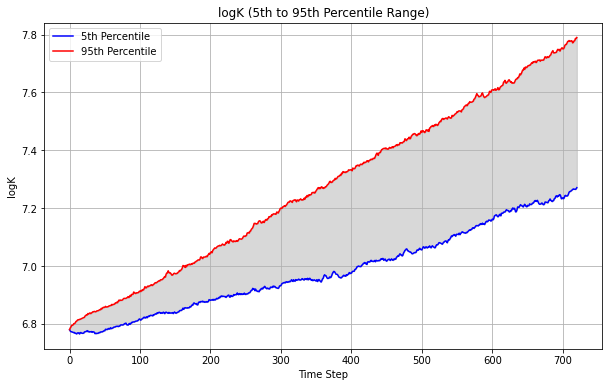

Processing variable: Z


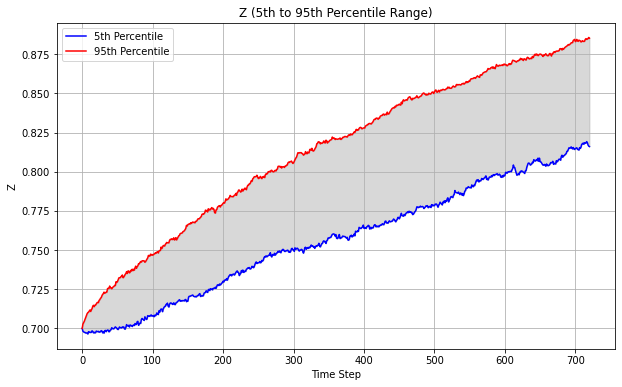

Processing variable: log_R


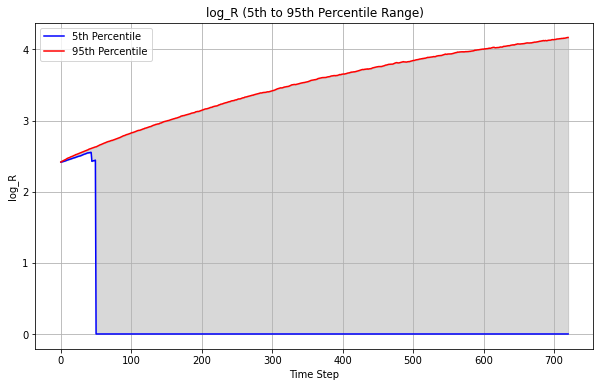

Processing variable: Y


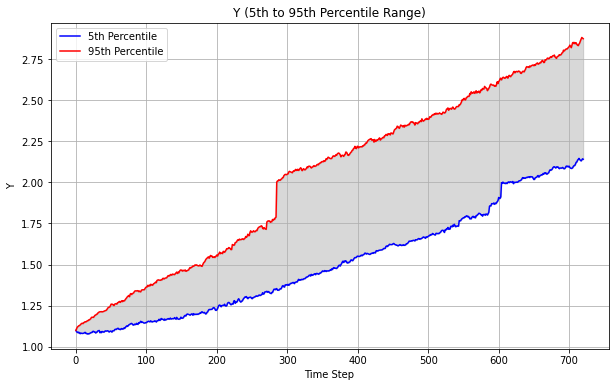

In [1]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt

# Folder where the simulation results are stored.
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters/Simulation/paths#100'

# Dictionary to map a variable label (for plotting) to the prefix used in file names.
# Adjust the keys and prefixes if needed.
variables = {
    'logK':   'logK_sim',      # files like logK_sim_1.npy, logK_sim_2.npy, ...
    'Z':      'R_array',       # files like R_array_1.npy, R_array_2.npy, ...
    'log_R': 'log_I_g_array', # files like log_I_g_array_1.npy, log_I_g_array_2.npy, ...
    'Y':      'Y_array'        # files like Y_array_1.npy, Y_array_2.npy, ...
}

def load_and_concatenate(folder, prefix):
    """
    Loads all .npy files in the given folder that start with the specified prefix.
    Each file is assumed to be a 2D NumPy array of shape (paths_per_file, time_steps).
    Concatenates them along the first axis so that all simulation paths from all files are merged.
    
    Parameters:
        folder (str): The directory path where the files are stored.
        prefix (str): The file name prefix, e.g. 'log_I_g_array'.
        
    Returns:
        np.ndarray: A 2D NumPy array with shape (total_paths, time_steps). 
        If no files are found, returns None.
    """
    files = []
    for fname in os.listdir(folder):
        if fname.startswith(prefix) and fname.endswith('.npy'):
            files.append(os.path.join(folder, fname))
    if not files:
        print(f"No files found for prefix '{prefix}' in folder '{folder}'")
        return None
    # Sort files to have a consistent ordering (assumes naming scheme like prefix_1.npy, prefix_2.npy, ...)
    files = sorted(files)
    
    data_list = []
    for f in files:
        data = np.load(f)
        # data is assumed to be 2D: (paths_per_file, time_steps)
        data_list.append(data)
    # Concatenate along the 0th axis to combine all paths into one array.
    return np.concatenate(data_list, axis=0)

# Loop over each variable, load the data, compute the percentiles, and plot.
for var_label, prefix in variables.items():
    print(f"Processing variable: {var_label}")
    data = load_and_concatenate(data_folder, prefix)
    if data is None:
        continue
    
    # data: shape (total_paths, time_steps)
    # Compute the 5th and 95th percentiles at each time step (over all paths).
    lower_percentile = np.percentile(data, 5, axis=0)
    upper_percentile = np.percentile(data, 95, axis=0)
    
    # Create a time vector assuming time is along the columns.
    time_steps = np.arange(data.shape[1])
    
    # Plot the percentile bands.
    plt.figure(figsize=(10, 6))
    plt.plot(time_steps, lower_percentile, label='5th Percentile', color='blue')
    plt.plot(time_steps, upper_percentile, label='95th Percentile', color='red')
    plt.fill_between(time_steps, lower_percentile, upper_percentile, color='gray', alpha=0.3)
    plt.xlabel('Time Step')
    plt.ylabel(var_label)
    plt.title(f'{var_label} (5th to 95th Percentile Range)')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()


In [13]:
tf.exp(5.0)

<tf.Tensor: shape=(), dtype=float32, numpy=148.41316>

Processing variable: log K


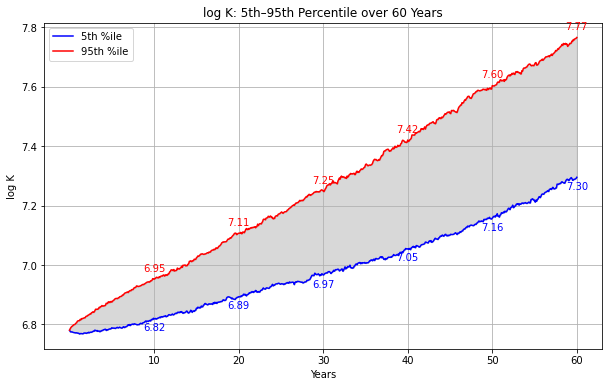

Processing variable: Z


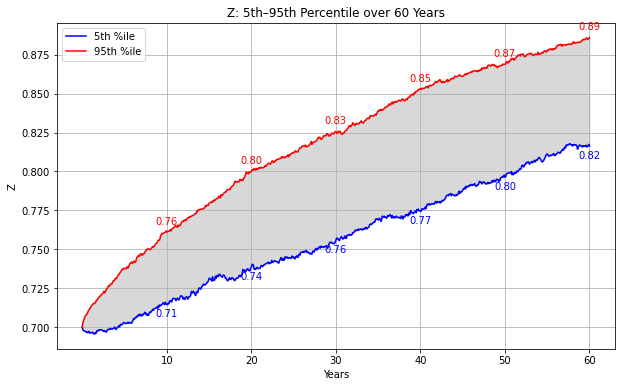

Processing variable: log R


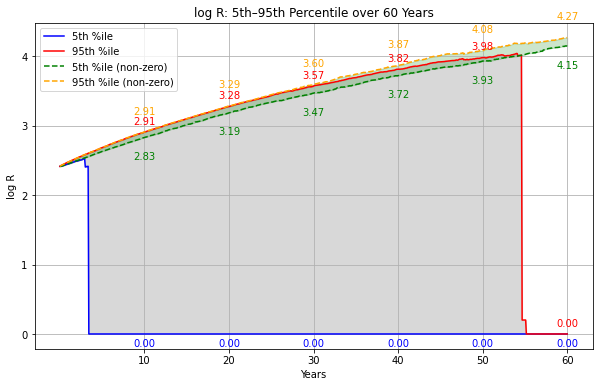

Processing variable: Y


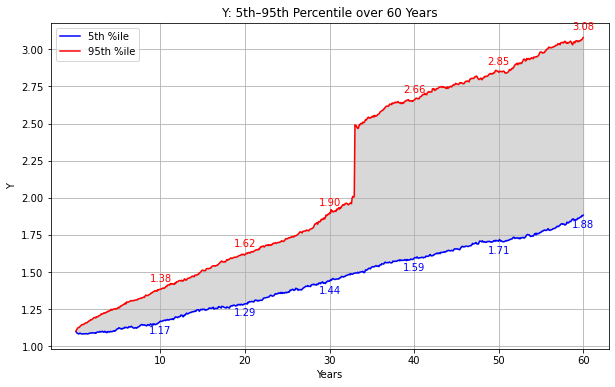

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Folder where the simulation results are stored.
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation_Y/paths_xi_0.075'

variables = {
    'log K':   'logK_sim',
    'Z':      'R_array',
    'log R':  'log_I_g_array',   # here log_R is actually your log_I_g_array
    'Y':      'Y_array'
}

def load_and_concatenate(folder, prefix):
    files = [os.path.join(folder, f) 
             for f in os.listdir(folder) 
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        print(f"No files found for prefix '{prefix}' in folder '{folder}'")
        return None
    files.sort()
    data_list = [np.load(f) for f in files]
    return np.concatenate(data_list, axis=0)

for var_label, prefix in variables.items():
    print(f"Processing variable: {var_label}")
    data = load_and_concatenate(data_folder, prefix)
    if data is None:
        continue

    # number of months
    n_months = data.shape[1]
    # convert month indices to years
    time_months = np.arange(n_months)
    time_years  = time_months / 12.0

    # compute 5th & 95th percentiles including zeros
    lower = np.percentile(data, 5, axis=0)
    upper = np.percentile(data, 95, axis=0)

    # set up the figure
    plt.figure(figsize=(10, 6))
    plt.plot(time_years, lower, label='5th %ile', color='blue')
    plt.plot(time_years, upper, label='95th %ile', color='red')
    plt.fill_between(time_years, lower, upper, color='gray', alpha=0.3)

    # decide decade ticks up to max full decade in your sim
    max_year = np.floor(time_years[-1])
    decade_ticks = np.arange(10, max_year+1, 10)
    plt.xticks(decade_ticks)
    plt.xlabel('Years')
    plt.ylabel(var_label)
    plt.title(f'{var_label}: 5th–95th Percentile over {max_year:.0f} Years')

    # annotate the two lines at each decade
    for year in decade_ticks:
        idx = int(year * 12)  # convert back to month index
        y_low = lower[idx]
        y_up  = upper[idx]
        plt.annotate(f"{y_low:.2f}", (year, y_low),
                     textcoords="offset points", xytext=(0,-12),
                     ha='center', color='blue')
        plt.annotate(f"{y_up:.2f}",  (year, y_up),
                     textcoords="offset points", xytext=(0,  8),
                     ha='center', color='red')

    # --- extra for log_I_g_array: exclude zeros and re‑plot percentiles ---
    if prefix == 'log_I_g_array':
        # compute percentiles at each t over non‑zero paths
        lower_nz = np.empty(n_months)
        upper_nz = np.empty(n_months)
        for t in range(n_months):
            col = data[:, t]
            nz  = col[col != 0]
            if nz.size:
                lower_nz[t] = np.percentile(nz, 5)
                upper_nz[t] = np.percentile(nz, 95)
            else:
                lower_nz[t] = np.nan
                upper_nz[t] = np.nan

        plt.plot(time_years, lower_nz, '--', label='5th %ile (non‑zero)', color='green')
        plt.plot(time_years, upper_nz, '--', label='95th %ile (non‑zero)', color='orange')
        plt.fill_between(time_years, lower_nz, upper_nz, color='green', alpha=0.2)

        # annotate the non‑zero lines
        for year in decade_ticks:
            idx = int(year * 12)
            y_lz = lower_nz[idx]
            y_uz = upper_nz[idx]
            if not np.isnan(y_lz):
                plt.annotate(f"{y_lz:.2f}", (year, y_lz),
                             textcoords="offset points", xytext=(0,-22),
                             ha='center', color='green')
            if not np.isnan(y_uz):
                plt.annotate(f"{y_uz:.2f}", (year, y_uz),
                             textcoords="offset points", xytext=(0, 18),
                             ha='center', color='orange')

    plt.legend(loc='best')
    plt.grid(True)
    plt.show()


## New Resaults

Processing variable: log K


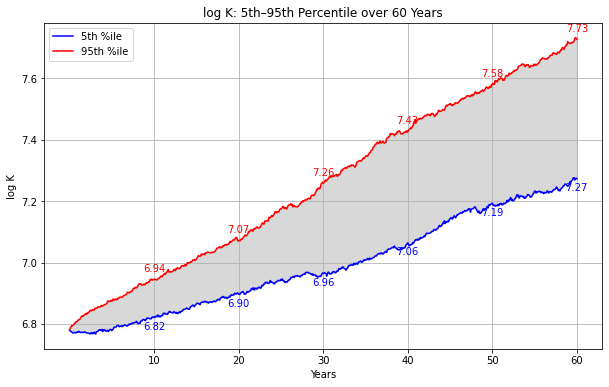

Processing variable: Z


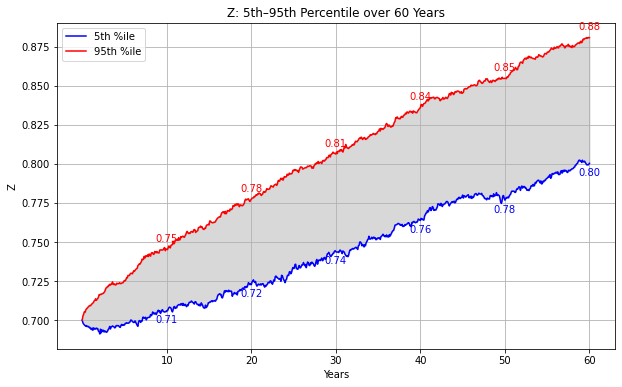

Processing variable: log R


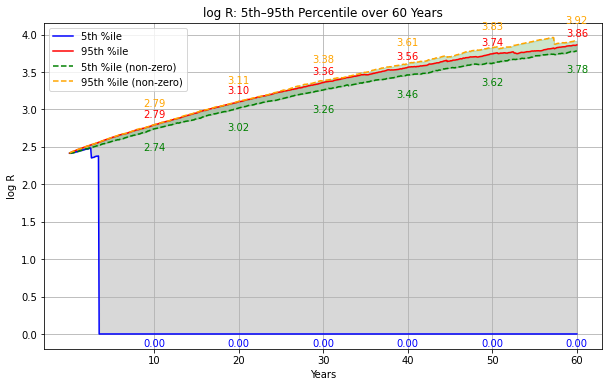

Processing variable: Y


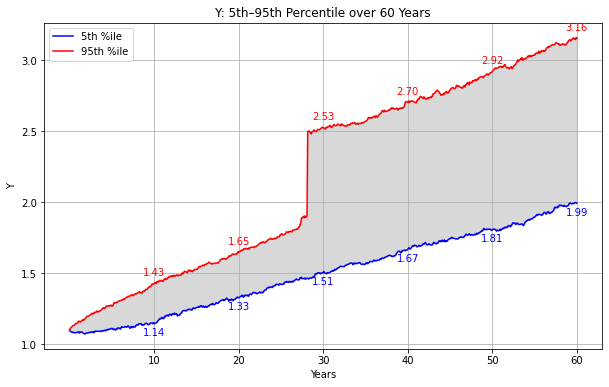

In [3]:

# Folder where the simulation results are stored.
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation_New/paths_xi_0.075'

variables = {
    'log K':   'logK_sim',
    'Z':      'R_array',
    'log R':  'log_I_g_array',   # here log_R is actually your log_I_g_array
    'Y':      'Y_array'
}

def load_and_concatenate(folder, prefix):
    files = [os.path.join(folder, f) 
             for f in os.listdir(folder) 
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        print(f"No files found for prefix '{prefix}' in folder '{folder}'")
        return None
    files.sort()
    data_list = [np.load(f) for f in files]
    return np.concatenate(data_list, axis=0)

for var_label, prefix in variables.items():
    print(f"Processing variable: {var_label}")
    data = load_and_concatenate(data_folder, prefix)
    if data is None:
        continue

    # number of months
    n_months = data.shape[1]
    # convert month indices to years
    time_months = np.arange(n_months)
    time_years  = time_months / 12.0

    # compute 5th & 95th percentiles including zeros
    lower = np.percentile(data, 5, axis=0)
    upper = np.percentile(data, 95, axis=0)

    # set up the figure
    plt.figure(figsize=(10, 6))
    plt.plot(time_years, lower, label='5th %ile', color='blue')
    plt.plot(time_years, upper, label='95th %ile', color='red')
    plt.fill_between(time_years, lower, upper, color='gray', alpha=0.3)

    # decide decade ticks up to max full decade in your sim
    max_year = np.floor(time_years[-1])
    decade_ticks = np.arange(10, max_year+1, 10)
    plt.xticks(decade_ticks)
    plt.xlabel('Years')
    plt.ylabel(var_label)
    plt.title(f'{var_label}: 5th–95th Percentile over {max_year:.0f} Years')

    # annotate the two lines at each decade
    for year in decade_ticks:
        idx = int(year * 12)  # convert back to month index
        y_low = lower[idx]
        y_up  = upper[idx]
        plt.annotate(f"{y_low:.2f}", (year, y_low),
                     textcoords="offset points", xytext=(0,-12),
                     ha='center', color='blue')
        plt.annotate(f"{y_up:.2f}",  (year, y_up),
                     textcoords="offset points", xytext=(0,  8),
                     ha='center', color='red')

    # --- extra for log_I_g_array: exclude zeros and re‑plot percentiles ---
    if prefix == 'log_I_g_array':
        # compute percentiles at each t over non‑zero paths
        lower_nz = np.empty(n_months)
        upper_nz = np.empty(n_months)
        for t in range(n_months):
            col = data[:, t]
            nz  = col[col != 0]
            if nz.size:
                lower_nz[t] = np.percentile(nz, 5)
                upper_nz[t] = np.percentile(nz, 95)
            else:
                lower_nz[t] = np.nan
                upper_nz[t] = np.nan

        plt.plot(time_years, lower_nz, '--', label='5th %ile (non‑zero)', color='green')
        plt.plot(time_years, upper_nz, '--', label='95th %ile (non‑zero)', color='orange')
        plt.fill_between(time_years, lower_nz, upper_nz, color='green', alpha=0.2)

        # annotate the non‑zero lines
        for year in decade_ticks:
            idx = int(year * 12)
            y_lz = lower_nz[idx]
            y_uz = upper_nz[idx]
            if not np.isnan(y_lz):
                plt.annotate(f"{y_lz:.2f}", (year, y_lz),
                             textcoords="offset points", xytext=(0,-22),
                             ha='center', color='green')
            if not np.isnan(y_uz):
                plt.annotate(f"{y_uz:.2f}", (year, y_uz),
                             textcoords="offset points", xytext=(0, 18),
                             ha='center', color='orange')

    plt.legend(loc='best')
    plt.grid(True)
    plt.show()


Processing variable: log K


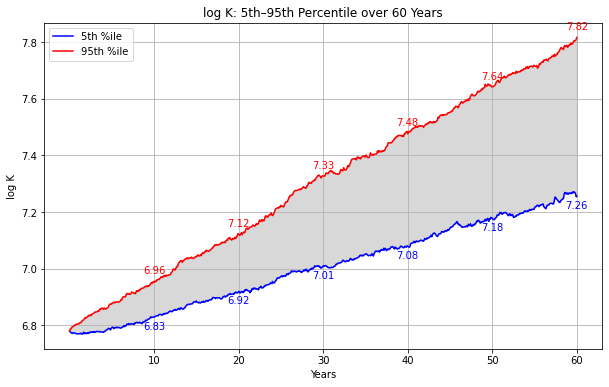

Processing variable: Z


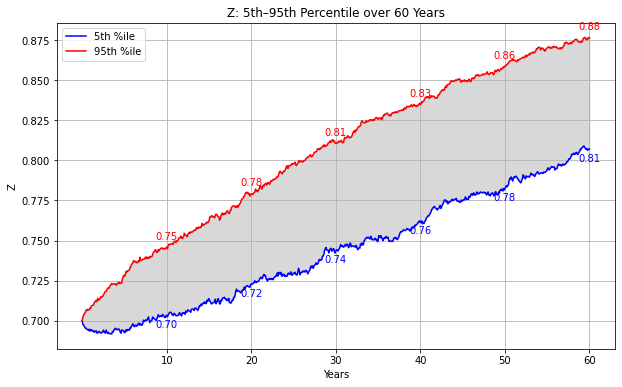

Processing variable: log R


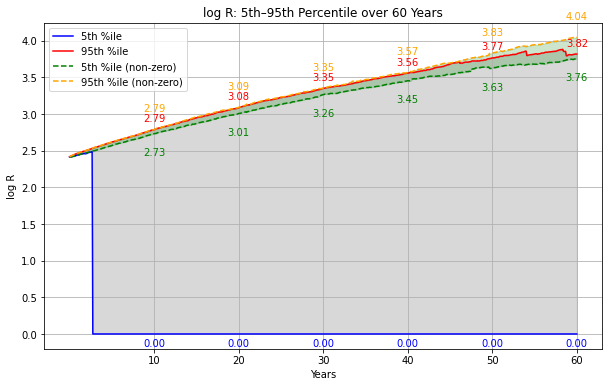

Processing variable: Y


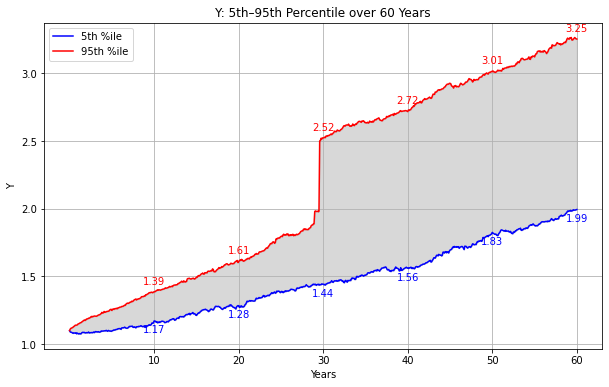

In [2]:

# Folder where the simulation results are stored.
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation_New/paths_xi_0.3'

variables = {
    'log K':   'logK_sim',
    'Z':      'R_array',
    'log R':  'log_I_g_array',   # here log_R is actually your log_I_g_array
    'Y':      'Y_array'
}

def load_and_concatenate(folder, prefix):
    files = [os.path.join(folder, f) 
             for f in os.listdir(folder) 
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        print(f"No files found for prefix '{prefix}' in folder '{folder}'")
        return None
    files.sort()
    data_list = [np.load(f) for f in files]
    return np.concatenate(data_list, axis=0)

for var_label, prefix in variables.items():
    print(f"Processing variable: {var_label}")
    data = load_and_concatenate(data_folder, prefix)
    if data is None:
        continue

    # number of months
    n_months = data.shape[1]
    # convert month indices to years
    time_months = np.arange(n_months)
    time_years  = time_months / 12.0

    # compute 5th & 95th percentiles including zeros
    lower = np.percentile(data, 5, axis=0)
    upper = np.percentile(data, 95, axis=0)

    # set up the figure
    plt.figure(figsize=(10, 6))
    plt.plot(time_years, lower, label='5th %ile', color='blue')
    plt.plot(time_years, upper, label='95th %ile', color='red')
    plt.fill_between(time_years, lower, upper, color='gray', alpha=0.3)

    # decide decade ticks up to max full decade in your sim
    max_year = np.floor(time_years[-1])
    decade_ticks = np.arange(10, max_year+1, 10)
    plt.xticks(decade_ticks)
    plt.xlabel('Years')
    plt.ylabel(var_label)
    plt.title(f'{var_label}: 5th–95th Percentile over {max_year:.0f} Years')

    # annotate the two lines at each decade
    for year in decade_ticks:
        idx = int(year * 12)  # convert back to month index
        y_low = lower[idx]
        y_up  = upper[idx]
        plt.annotate(f"{y_low:.2f}", (year, y_low),
                     textcoords="offset points", xytext=(0,-12),
                     ha='center', color='blue')
        plt.annotate(f"{y_up:.2f}",  (year, y_up),
                     textcoords="offset points", xytext=(0,  8),
                     ha='center', color='red')

    # --- extra for log_I_g_array: exclude zeros and re‑plot percentiles ---
    if prefix == 'log_I_g_array':
        # compute percentiles at each t over non‑zero paths
        lower_nz = np.empty(n_months)
        upper_nz = np.empty(n_months)
        for t in range(n_months):
            col = data[:, t]
            nz  = col[col != 0]
            if nz.size:
                lower_nz[t] = np.percentile(nz, 5)
                upper_nz[t] = np.percentile(nz, 95)
            else:
                lower_nz[t] = np.nan
                upper_nz[t] = np.nan

        plt.plot(time_years, lower_nz, '--', label='5th %ile (non‑zero)', color='green')
        plt.plot(time_years, upper_nz, '--', label='95th %ile (non‑zero)', color='orange')
        plt.fill_between(time_years, lower_nz, upper_nz, color='green', alpha=0.2)

        # annotate the non‑zero lines
        for year in decade_ticks:
            idx = int(year * 12)
            y_lz = lower_nz[idx]
            y_uz = upper_nz[idx]
            if not np.isnan(y_lz):
                plt.annotate(f"{y_lz:.2f}", (year, y_lz),
                             textcoords="offset points", xytext=(0,-22),
                             ha='center', color='green')
            if not np.isnan(y_uz):
                plt.annotate(f"{y_uz:.2f}", (year, y_uz),
                             textcoords="offset points", xytext=(0, 18),
                             ha='center', color='orange')

    plt.legend(loc='best')
    plt.grid(True)
    plt.show()


Processing variable: log K


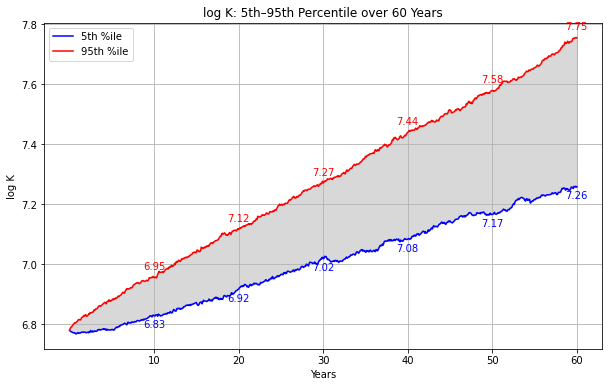

Processing variable: Z


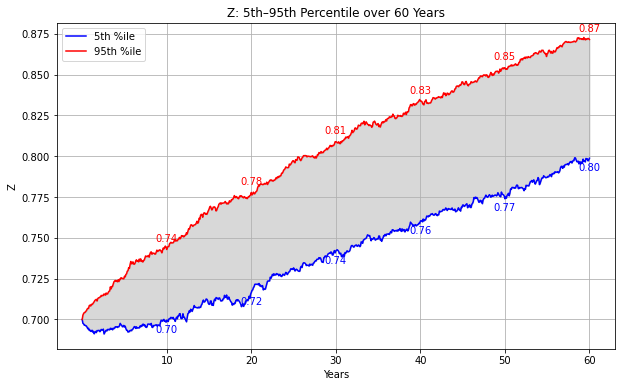

Processing variable: log R


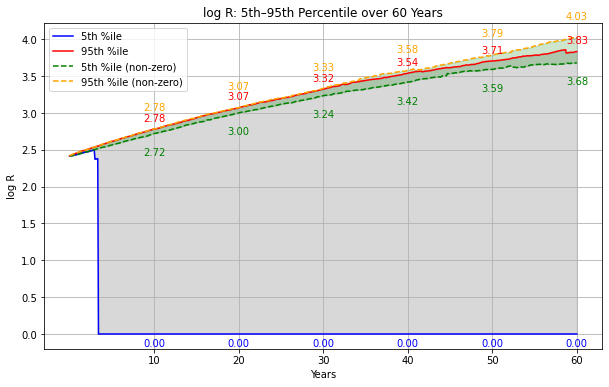

Processing variable: Y


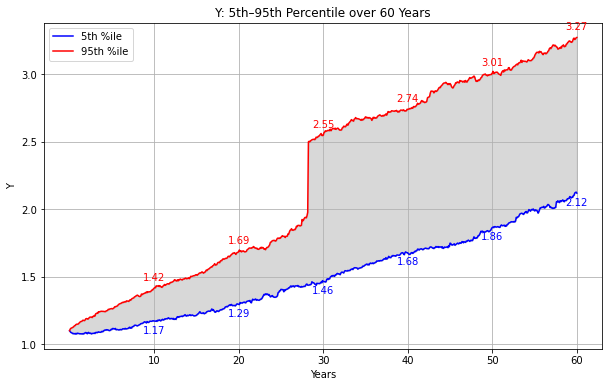

In [ ]:

# Folder where the simulation results are stored.
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation_New/paths_xi_148.4'

variables = {
    'log K':   'logK_sim',
    'Z':      'Z_array',
    'log R':  'logR_array',   # here log_R is actually your log_I_g_array
    'Y':      'Y_array'
}

def load_and_concatenate(folder, prefix):
    files = [os.path.join(folder, f) 
             for f in os.listdir(folder) 
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        print(f"No files found for prefix '{prefix}' in folder '{folder}'")
        return None
    files.sort()
    data_list = [np.load(f) for f in files]
    return np.concatenate(data_list, axis=0)

for var_label, prefix in variables.items():
    print(f"Processing variable: {var_label}")
    data = load_and_concatenate(data_folder, prefix)
    if data is None:
        continue

    # number of months
    n_months = data.shape[1]
    # convert month indices to years
    time_months = np.arange(n_months)
    time_years  = time_months / 12.0

    # compute 5th & 95th percentiles including zeros
    lower = np.percentile(data, 5, axis=0)
    upper = np.percentile(data, 95, axis=0)

    # set up the figure
    plt.figure(figsize=(10, 6))
    plt.plot(time_years, lower, label='5th %ile', color='blue')
    plt.plot(time_years, upper, label='95th %ile', color='red')
    plt.fill_between(time_years, lower, upper, color='gray', alpha=0.3)

    # decide decade ticks up to max full decade in your sim
    max_year = np.floor(time_years[-1])
    decade_ticks = np.arange(10, max_year+1, 10)
    plt.xticks(decade_ticks)
    plt.xlabel('Years')
    plt.ylabel(var_label)
    plt.title(f'{var_label}: 5th–95th Percentile over {max_year:.0f} Years')

    # annotate the two lines at each decade
    for year in decade_ticks:
        idx = int(year * 12)  # convert back to month index
        y_low = lower[idx]
        y_up  = upper[idx]
        plt.annotate(f"{y_low:.2f}", (year, y_low),
                     textcoords="offset points", xytext=(0,-12),
                     ha='center', color='blue')
        plt.annotate(f"{y_up:.2f}",  (year, y_up),
                     textcoords="offset points", xytext=(0,  8),
                     ha='center', color='red')

    # --- extra for log_I_g_array: exclude zeros and re‑plot percentiles ---
    if prefix == 'log_I_g_array':
        # compute percentiles at each t over non‑zero paths
        lower_nz = np.empty(n_months)
        upper_nz = np.empty(n_months)
        for t in range(n_months):
            col = data[:, t]
            nz  = col[col != 0]
            if nz.size:
                lower_nz[t] = np.percentile(nz, 5)
                upper_nz[t] = np.percentile(nz, 95)
            else:
                lower_nz[t] = np.nan
                upper_nz[t] = np.nan

        plt.plot(time_years, lower_nz, '--', label='5th %ile (non‑zero)', color='green')
        plt.plot(time_years, upper_nz, '--', label='95th %ile (non‑zero)', color='orange')
        plt.fill_between(time_years, lower_nz, upper_nz, color='green', alpha=0.2)

        # annotate the non‑zero lines
        for year in decade_ticks:
            idx = int(year * 12)
            y_lz = lower_nz[idx]
            y_uz = upper_nz[idx]
            if not np.isnan(y_lz):
                plt.annotate(f"{y_lz:.2f}", (year, y_lz),
                             textcoords="offset points", xytext=(0,-22),
                             ha='center', color='green')
            if not np.isnan(y_uz):
                plt.annotate(f"{y_uz:.2f}", (year, y_uz),
                             textcoords="offset points", xytext=(0, 18),
                             ha='center', color='orange')

    plt.legend(loc='best')
    plt.grid(True)
    plt.show()


Processing variable: log K


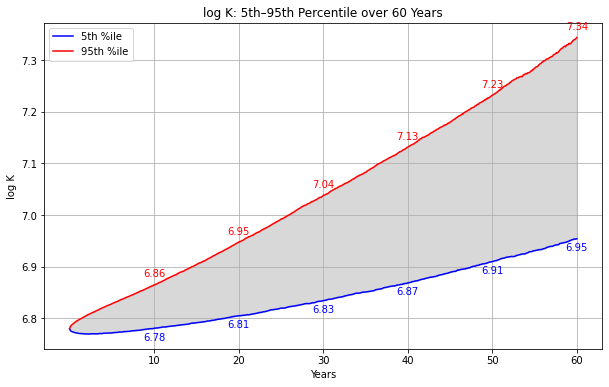

Processing variable: Z
No files found for prefix 'R_array' in folder '/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/SimulationResults/paths_ξ_0.1'
Processing variable: log R
No files found for prefix 'log_I_g_array' in folder '/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/SimulationResults/paths_ξ_0.1'
Processing variable: Y


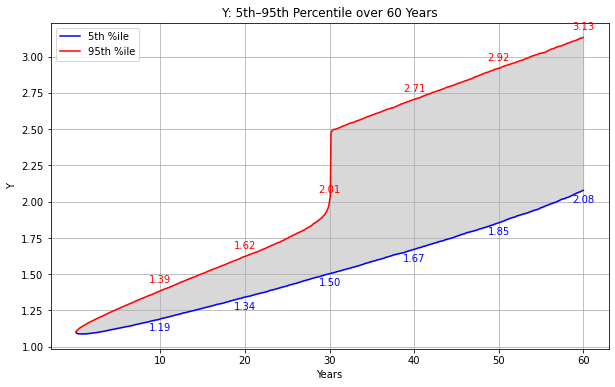

In [2]:

# Folder where the simulation results are stored.
data_folder = '/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/SimulationResults/paths_ξ_0.1'

variables = {
    'log K':   'logK_sim',
    'Z':      'R_array',
    'log R':  'log_I_g_array',   # here log_R is actually your log_I_g_array
    'Y':      'Y_array'
}

def load_and_concatenate(folder, prefix):
    files = [os.path.join(folder, f) 
             for f in os.listdir(folder) 
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        print(f"No files found for prefix '{prefix}' in folder '{folder}'")
        return None
    files.sort()
    data_list = [np.load(f) for f in files]
    return np.concatenate(data_list, axis=0)

for var_label, prefix in variables.items():
    print(f"Processing variable: {var_label}")
    data = load_and_concatenate(data_folder, prefix)
    if data is None:
        continue

    # number of months
    n_months = data.shape[1]
    # convert month indices to years
    time_months = np.arange(n_months)
    time_years  = time_months / 12.0

    # compute 5th & 95th percentiles including zeros
    lower = np.percentile(data, 5, axis=0)
    upper = np.percentile(data, 95, axis=0)

    # set up the figure
    plt.figure(figsize=(10, 6))
    plt.plot(time_years, lower, label='5th %ile', color='blue')
    plt.plot(time_years, upper, label='95th %ile', color='red')
    plt.fill_between(time_years, lower, upper, color='gray', alpha=0.3)

    # decide decade ticks up to max full decade in your sim
    max_year = np.floor(time_years[-1])
    decade_ticks = np.arange(10, max_year+1, 10)
    plt.xticks(decade_ticks)
    plt.xlabel('Years')
    plt.ylabel(var_label)
    plt.title(f'{var_label}: 5th–95th Percentile over {max_year:.0f} Years')

    # annotate the two lines at each decade
    for year in decade_ticks:
        idx = int(year * 12)  # convert back to month index
        y_low = lower[idx]
        y_up  = upper[idx]
        plt.annotate(f"{y_low:.2f}", (year, y_low),
                     textcoords="offset points", xytext=(0,-12),
                     ha='center', color='blue')
        plt.annotate(f"{y_up:.2f}",  (year, y_up),
                     textcoords="offset points", xytext=(0,  8),
                     ha='center', color='red')

    # --- extra for log_I_g_array: exclude zeros and re‑plot percentiles ---
    if prefix == 'log_I_g_array':
        # compute percentiles at each t over non‑zero paths
        lower_nz = np.empty(n_months)
        upper_nz = np.empty(n_months)
        for t in range(n_months):
            col = data[:, t]
            nz  = col[col != 0]
            if nz.size:
                lower_nz[t] = np.percentile(nz, 5)
                upper_nz[t] = np.percentile(nz, 95)
            else:
                lower_nz[t] = np.nan
                upper_nz[t] = np.nan

        plt.plot(time_years, lower_nz, '--', label='5th %ile (non‑zero)', color='green')
        plt.plot(time_years, upper_nz, '--', label='95th %ile (non‑zero)', color='orange')
        plt.fill_between(time_years, lower_nz, upper_nz, color='green', alpha=0.2)

        # annotate the non‑zero lines
        for year in decade_ticks:
            idx = int(year * 12)
            y_lz = lower_nz[idx]
            y_uz = upper_nz[idx]
            if not np.isnan(y_lz):
                plt.annotate(f"{y_lz:.2f}", (year, y_lz),
                             textcoords="offset points", xytext=(0,-22),
                             ha='center', color='green')
            if not np.isnan(y_uz):
                plt.annotate(f"{y_uz:.2f}", (year, y_uz),
                             textcoords="offset points", xytext=(0, 18),
                             ha='center', color='orange')

    plt.legend(loc='best')
    plt.grid(True)
    plt.show()


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Folder where the simulation results are stored.
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation/paths_xi_0.075'

variables = {
    'log K':   'logK_sim',
    'Z':      'R_array',
    'log R':  'log_I_g_array',   # here log_R is actually your log_I_g_array
    'Y':      'Y_array'
}

def load_and_concatenate(folder, prefix):
    files = [os.path.join(folder, f) 
             for f in os.listdir(folder) 
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        print(f"No files found for prefix '{prefix}' in folder '{folder}'")
        return None
    files.sort()
    data_list = [np.load(f) for f in files]
    return np.concatenate(data_list, axis=0)

for var_label, prefix in variables.items():
    print(f"Processing variable: {var_label}")
    data = load_and_concatenate(data_folder, prefix)
    if data is None:
        continue

    # number of months
    n_months = data.shape[1]
    # convert month indices to years
    time_months = np.arange(n_months)
    time_years  = time_months / 12.0

    # compute 5th & 95th percentiles including zeros
    lower = np.percentile(data, 5, axis=0)
    upper = np.percentile(data, 95, axis=0)

    # set up the figure
    plt.figure(figsize=(10, 6))
    plt.plot(time_years, lower, label='5th %ile', color='blue')
    plt.plot(time_years, upper, label='95th %ile', color='red')
    plt.fill_between(time_years, lower, upper, color='gray', alpha=0.3)

    # decide decade ticks up to max full decade in your sim
    max_year = np.floor(time_years[-1])
    decade_ticks = np.arange(10, max_year+1, 10)
    plt.xticks(decade_ticks)
    plt.xlabel('Years')
    plt.ylabel(var_label)
    plt.title(f'{var_label}: 5th–95th Percentile over {max_year:.0f} Years')

    # annotate the two lines at each decade
    for year in decade_ticks:
        idx = int(year * 12)  # convert back to month index
        y_low = lower[idx]
        y_up  = upper[idx]
        plt.annotate(f"{y_low:.2f}", (year, y_low),
                     textcoords="offset points", xytext=(0,-12),
                     ha='center', color='blue')
        plt.annotate(f"{y_up:.2f}",  (year, y_up),
                     textcoords="offset points", xytext=(0,  8),
                     ha='center', color='red')

    # --- extra for log_I_g_array: exclude zeros and re‑plot percentiles ---
    if prefix == 'log_I_g_array':
        # compute percentiles at each t over non‑zero paths
        lower_nz = np.empty(n_months)
        upper_nz = np.empty(n_months)
        for t in range(n_months):
            col = data[:, t]
            nz  = col[col != 0]
            if nz.size:
                lower_nz[t] = np.percentile(nz, 5)
                upper_nz[t] = np.percentile(nz, 95)
            else:
                lower_nz[t] = np.nan
                upper_nz[t] = np.nan

        plt.plot(time_years, lower_nz, '--', label='5th %ile (non‑zero)', color='green')
        plt.plot(time_years, upper_nz, '--', label='95th %ile (non‑zero)', color='orange')
        plt.fill_between(time_years, lower_nz, upper_nz, color='green', alpha=0.2)

        # annotate the non‑zero lines
        for year in decade_ticks:
            idx = int(year * 12)
            y_lz = lower_nz[idx]
            y_uz = upper_nz[idx]
            if not np.isnan(y_lz):
                plt.annotate(f"{y_lz:.2f}", (year, y_lz),
                             textcoords="offset points", xytext=(0,-22),
                             ha='center', color='green')
            if not np.isnan(y_uz):
                plt.annotate(f"{y_uz:.2f}", (year, y_uz),
                             textcoords="offset points", xytext=(0, 18),
                             ha='center', color='orange')

    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

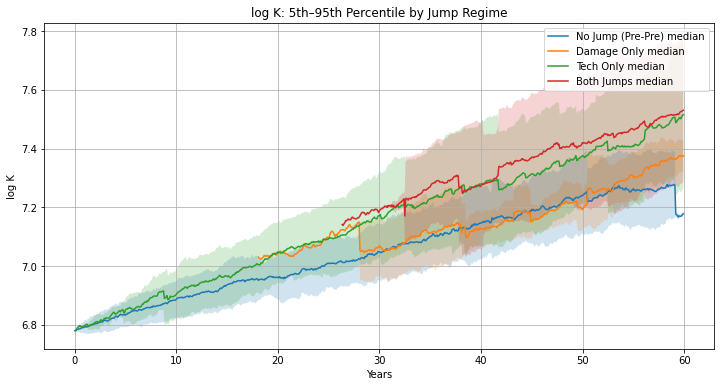

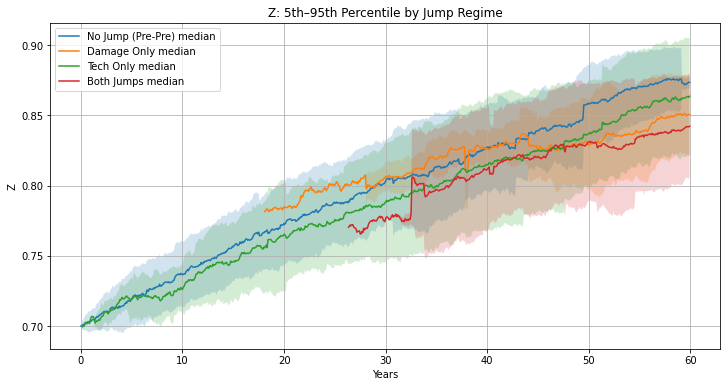

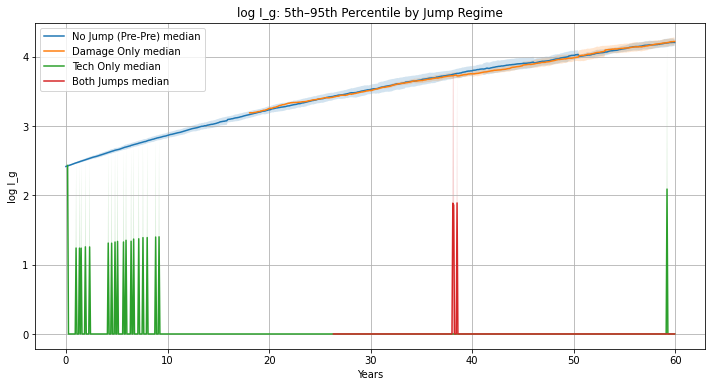

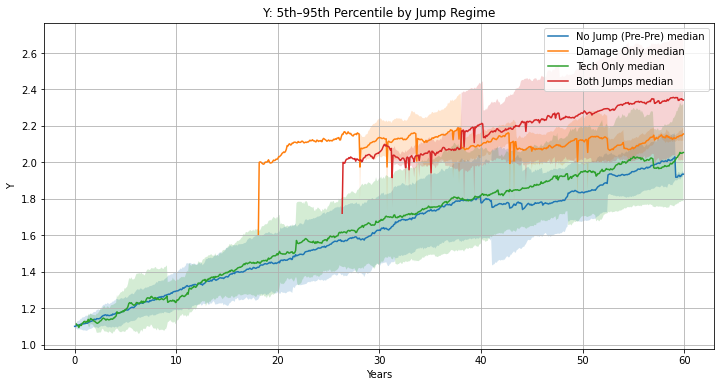

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Folder where the simulation results are stored.
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation/paths_xi_0.1'

# Variable prefixes and labels
variables = {
    'log K':   'logK_sim',
    'Z':       'R_array',
    'log I_g': 'log_I_g_array',
    'Y':       'Y_array'
}

def load_and_concatenate(folder, prefix):
    """
    Load all .npy files in `folder` starting with `prefix` and concatenate along the first axis.
    """
    files = [os.path.join(folder, f) 
             for f in os.listdir(folder) 
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        raise FileNotFoundError(f"No files found for prefix '{prefix}'")
    files.sort()
    arrays = [np.load(f) for f in files]
    return np.concatenate(arrays, axis=0)

# Load jump indicator arrays across all seeds
tech_jump = load_and_concatenate(data_folder, 'tech_jump_array_')
damage_jump = load_and_concatenate(data_folder, 'damage_jump_array_')

# Define jump regime masks
regimes = {
    'No Jump (Pre-Pre)': (tech_jump == 0) & (damage_jump == 0),
    'Damage Only':       (tech_jump == 0) & (damage_jump == 1),
    'Tech Only':         (tech_jump == 1) & (damage_jump == 0),
    'Both Jumps':        (tech_jump == 1) & (damage_jump == 1),
}

# Time axis (in years)
n_months = tech_jump.shape[1]
time_years = np.arange(n_months) / 12.0

# Plot each variable by jump regime
for label, prefix in variables.items():
    data = load_and_concatenate(data_folder, prefix)
    
    plt.figure(figsize=(12, 6))
    for regime, mask in regimes.items():
        lower = np.full(n_months, np.nan)
        upper = np.full(n_months, np.nan)
        for t in range(n_months):
            paths = data[mask[:, t], t]
            if paths.size > 0:
                lower[t] = np.percentile(paths, 5)
                upper[t] = np.percentile(paths, 95)
        median = (lower + upper) / 2
        plt.plot(time_years, median, label=f'{regime} median')
        plt.fill_between(time_years, lower, upper, alpha=0.2)
    
    plt.xlabel('Years')
    plt.ylabel(label)
    plt.title(f'{label}: 5th–95th Percentile by Jump Regime')
    plt.legend()
    plt.grid(True)
    plt.show()



Regime: No Jumps | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8853, 95th %ile = 7.0524
  Year 40: 5th %ile = 7.0289, 95th %ile = 7.2802
  Year 60: 5th %ile = 7.1867, 95th %ile = 7.3424

Regime: No Jumps | Variable: Return Share (Z)
  Year 20: 5th %ile = 0.7402, 95th %ile = 0.7903
  Year 40: 5th %ile = 0.7764, 95th %ile = 0.8460
  Year 60: 5th %ile = 0.8450, 95th %ile = 0.8622

Regime: No Jumps | Variable: Log R&D (logR)
  Year 20: 5th %ile = 3.1644, 95th %ile = 3.2610
  Year 40: 5th %ile = 3.6957, 95th %ile = 3.8350
  Year 60: 5th %ile = 4.0976, 95th %ile = 4.2698

Regime: No Jumps | Variable: Output (Y)
  Year 20: 5th %ile = 1.3281, 95th %ile = 1.6011
  Year 40: 5th %ile = 1.6515, 95th %ile = 2.0305
  Year 60: 5th %ile = 1.9800, 95th %ile = 2.1487


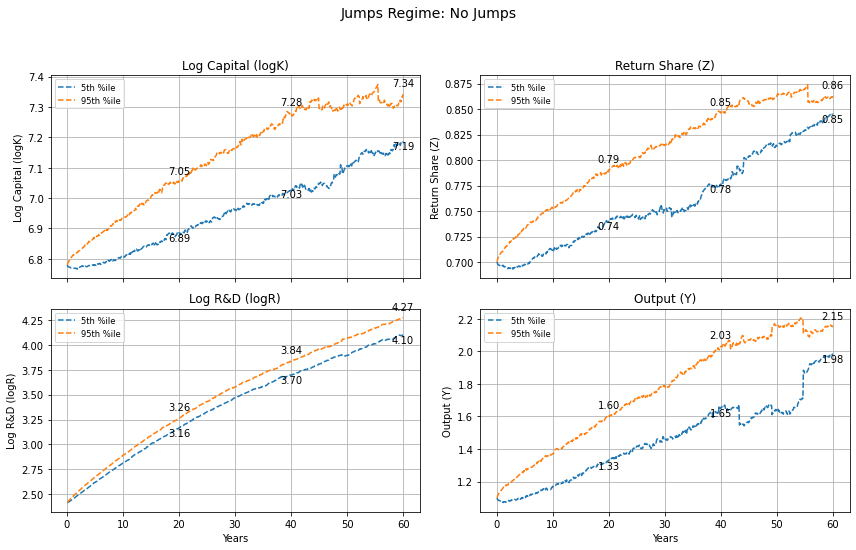


Regime: Damage Only | Variable: Log Capital (logK)
  Year 20: insufficient data
  Year 40: 5th %ile = 7.0207, 95th %ile = 7.1555
  Year 60: 5th %ile = 7.2913, 95th %ile = 7.5378

Regime: Damage Only | Variable: Return Share (Z)
  Year 20: insufficient data
  Year 40: 5th %ile = 0.7992, 95th %ile = 0.8485
  Year 60: 5th %ile = 0.8665, 95th %ile = 0.9064

Regime: Damage Only | Variable: Log R&D (logR)
  Year 20: insufficient data
  Year 40: 5th %ile = 3.7116, 95th %ile = 3.8394
  Year 60: 5th %ile = 4.1569, 95th %ile = 4.3229

Regime: Damage Only | Variable: Output (Y)
  Year 20: insufficient data
  Year 40: 5th %ile = 2.5004, 95th %ile = 2.5953
  Year 60: 5th %ile = 2.5503, 95th %ile = 2.9457


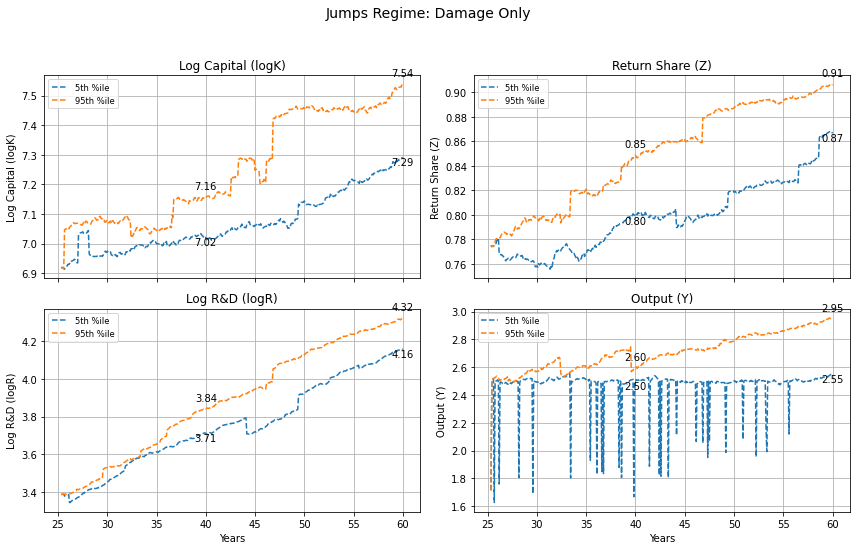


Regime: Tech Only | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.9184, 95th %ile = 7.1182
  Year 40: 5th %ile = 7.1196, 95th %ile = 7.4401
  Year 60: 5th %ile = 7.3152, 95th %ile = 7.7307

Regime: Tech Only | Variable: Return Share (Z)
  Year 20: 5th %ile = 0.7246, 95th %ile = 0.7859
  Year 40: 5th %ile = 0.7648, 95th %ile = 0.8437
  Year 60: 5th %ile = 0.8279, 95th %ile = 0.8891

Regime: Tech Only | Variable: Log R&D (logR)
  Year 20: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: Tech Only | Variable: Output (Y)
  Year 20: 5th %ile = 1.2919, 95th %ile = 1.6400
  Year 40: 5th %ile = 1.5531, 95th %ile = 2.0721
  Year 60: 5th %ile = 1.8187, 95th %ile = 2.3459


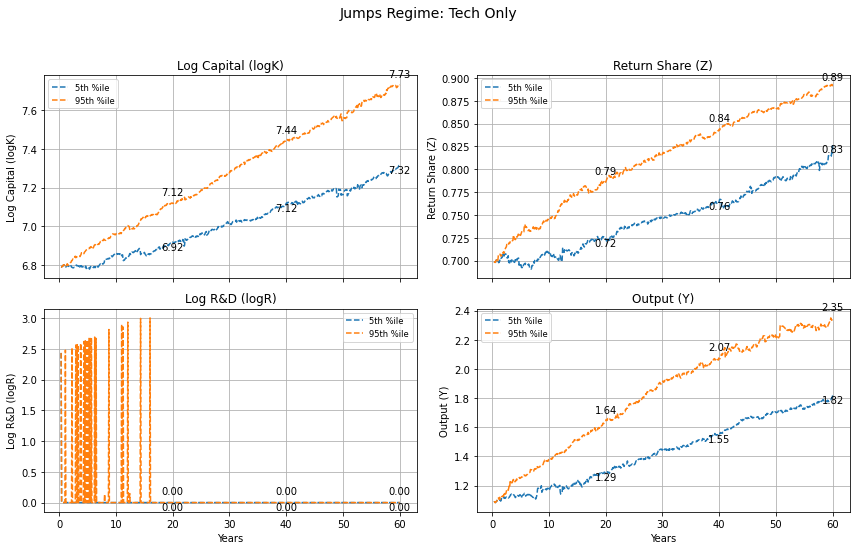


Regime: Both Jumps | Variable: Log Capital (logK)
  Year 20: insufficient data
  Year 40: 5th %ile = 7.0951, 95th %ile = 7.4879
  Year 60: 5th %ile = 7.2899, 95th %ile = 7.7814

Regime: Both Jumps | Variable: Return Share (Z)
  Year 20: insufficient data
  Year 40: 5th %ile = 0.7703, 95th %ile = 0.8415
  Year 60: 5th %ile = 0.8021, 95th %ile = 0.8781

Regime: Both Jumps | Variable: Log R&D (logR)
  Year 20: insufficient data
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: Both Jumps | Variable: Output (Y)
  Year 20: insufficient data
  Year 40: 5th %ile = 2.4769, 95th %ile = 2.8758
  Year 60: 5th %ile = 2.5066, 95th %ile = 3.0431


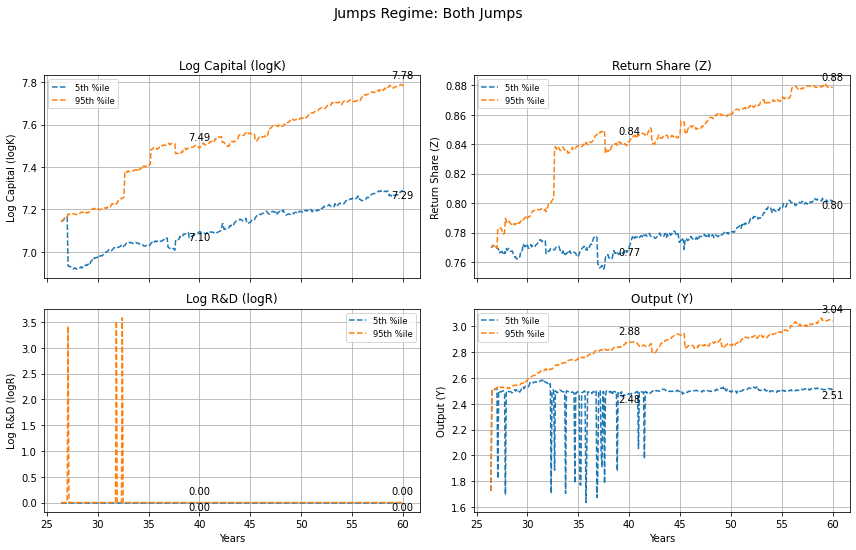

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---- EDIT THIS PATH to your actual simulation folder ----
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation_Y/paths_xi_0.3'

# Variables and their file prefixes
variables = {
    'Log Capital (logK)': 'logK_sim',
    'Return Share (Z)':   'R_array',
    'Log R&D (logR)':  'log_I_g_array',
    'Output (Y)':         'Y_array'
}

def load_and_concat(folder, prefix):
    """
    Find all .npy files in 'folder' starting with 'prefix', sort them,
    load and concatenate along the first axis.
    """
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        raise FileNotFoundError(f"No files for prefix '{prefix}' in {folder}")
    files.sort()
    arrays = [np.load(f) for f in files]
    return np.concatenate(arrays, axis=0)

# Load jump indicator arrays
tech_jump = load_and_concat(data_folder, 'tech_jump_array_')
damage_jump = load_and_concat(data_folder, 'damage_jump_array_')

# Ensure consistent time length
n_months = tech_jump.shape[1]

# Time axis in years (months 1 through n_months)
time_years = (np.arange(n_months) + 1) / 12.0

# Regime masks
regimes = {
    'No Jumps':         (tech_jump == 0) & (damage_jump == 0),
    'Damage Only':      (tech_jump == 0) & (damage_jump == 1),
    'Tech Only':        (tech_jump == 1) & (damage_jump == 0),
    'Both Jumps':       (tech_jump == 1) & (damage_jump == 1)
}

# Years at which to annotate percentiles
annot_years = [20, 40, 60]
# Corresponding indices in 0-based array
annot_idxs = [y * 12 - 1 for y in annot_years]

# Generate one figure per regime
for regime_label, mask in regimes.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()
    
    for ax, (var_label, prefix) in zip(axes, variables.items()):
        data = load_and_concat(data_folder, prefix)
        # Align to jump mask length
        if data.shape[1] > n_months:
            data = data[:, :n_months]
        
        # Compute 5th and 95th percentiles at each time step
        lower = np.full(n_months, np.nan)
        upper = np.full(n_months, np.nan)
        for t in range(n_months):
            values = data[mask[:, t], t]
            if values.size:
                lower[t] = np.percentile(values, 5)
                upper[t] = np.percentile(values, 95)
        
        
                # --- PRINT SELECTED‐YEAR PERCENTILES ---
        print(f"\nRegime: {regime_label} | Variable: {var_label}")
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                print(f"  Year {y:2d}: 5th %ile = {lower[idx]:.4f}, 95th %ile = {upper[idx]:.4f}")
            else:
                print(f"  Year {y:2d}: insufficient data")
        
        # Plot percentiles
        ax.plot(time_years, lower, linestyle='--', label='5th %ile')
        ax.plot(time_years, upper, linestyle='--', label='95th %ile')
        
        # Annotate at selected years
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                ax.annotate(f'{lower[idx]:.2f}', xy=(y, lower[idx]),
                            xytext=(0, -8), textcoords='offset points', ha='center')
            if not np.isnan(upper[idx]):
                ax.annotate(f'{upper[idx]:.2f}', xy=(y, upper[idx]),
                            xytext=(0,  8), textcoords='offset points', ha='center')
        
        ax.set_title(var_label)
        ax.set_ylabel(var_label)
        ax.grid(True)
        ax.legend(fontsize='small')
    
    # Final touches
    for ax in axes[2:]:
        ax.set_xlabel('Years')
    fig.suptitle(f'Jumps Regime: {regime_label}', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



Regime: No Jumps | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8936, 95th %ile = 7.0845
  Year 40: 5th %ile = 7.0449, 95th %ile = 7.2885
  Year 60: 5th %ile = 7.3884, 95th %ile = 7.4482

Regime: No Jumps | Variable: Return Share (Z)
  Year 20: 5th %ile = 0.7321, 95th %ile = 0.7911
  Year 40: 5th %ile = 0.7791, 95th %ile = 0.8530
  Year 60: 5th %ile = 0.8283, 95th %ile = 0.8796

Regime: No Jumps | Variable: Log R&D (logR)
  Year 20: 5th %ile = 3.1335, 95th %ile = 3.2493
  Year 40: 5th %ile = 3.6642, 95th %ile = 3.8141
  Year 60: 5th %ile = 4.1279, 95th %ile = 4.2166

Regime: No Jumps | Variable: Output (Y)
  Year 20: 5th %ile = 1.2567, 95th %ile = 1.6304
  Year 40: 5th %ile = 1.5096, 95th %ile = 1.9741
  Year 60: 5th %ile = 2.0334, 95th %ile = 2.0926


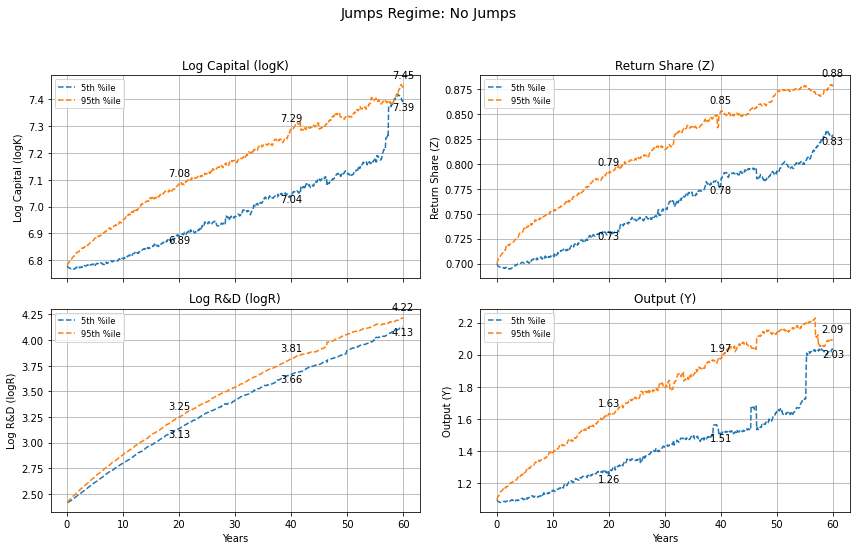


Regime: Damage Only | Variable: Log Capital (logK)
  Year 20: insufficient data
  Year 40: 5th %ile = 6.9872, 95th %ile = 7.1963
  Year 60: 5th %ile = 7.2437, 95th %ile = 7.4810

Regime: Damage Only | Variable: Return Share (Z)
  Year 20: insufficient data
  Year 40: 5th %ile = 0.7844, 95th %ile = 0.8365
  Year 60: 5th %ile = 0.8371, 95th %ile = 0.8943

Regime: Damage Only | Variable: Log R&D (logR)
  Year 20: insufficient data
  Year 40: 5th %ile = 3.6738, 95th %ile = 3.7929
  Year 60: 5th %ile = 4.1181, 95th %ile = 4.2724

Regime: Damage Only | Variable: Output (Y)
  Year 20: insufficient data
  Year 40: 5th %ile = 1.7278, 95th %ile = 2.7181
  Year 60: 5th %ile = 2.5117, 95th %ile = 2.9046


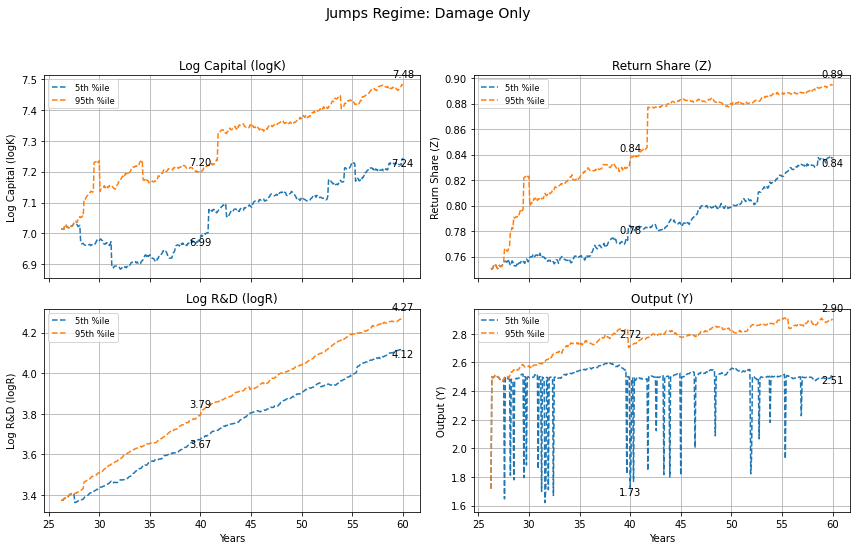


Regime: Tech Only | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.9396, 95th %ile = 7.1507
  Year 40: 5th %ile = 7.1221, 95th %ile = 7.4653
  Year 60: 5th %ile = 7.3414, 95th %ile = 7.7634

Regime: Tech Only | Variable: Return Share (Z)
  Year 20: 5th %ile = 0.7267, 95th %ile = 0.7852
  Year 40: 5th %ile = 0.7737, 95th %ile = 0.8438
  Year 60: 5th %ile = 0.8118, 95th %ile = 0.8890

Regime: Tech Only | Variable: Log R&D (logR)
  Year 20: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: Tech Only | Variable: Output (Y)
  Year 20: 5th %ile = 1.2952, 95th %ile = 1.6191
  Year 40: 5th %ile = 1.5514, 95th %ile = 2.0874
  Year 60: 5th %ile = 1.7961, 95th %ile = 2.3586


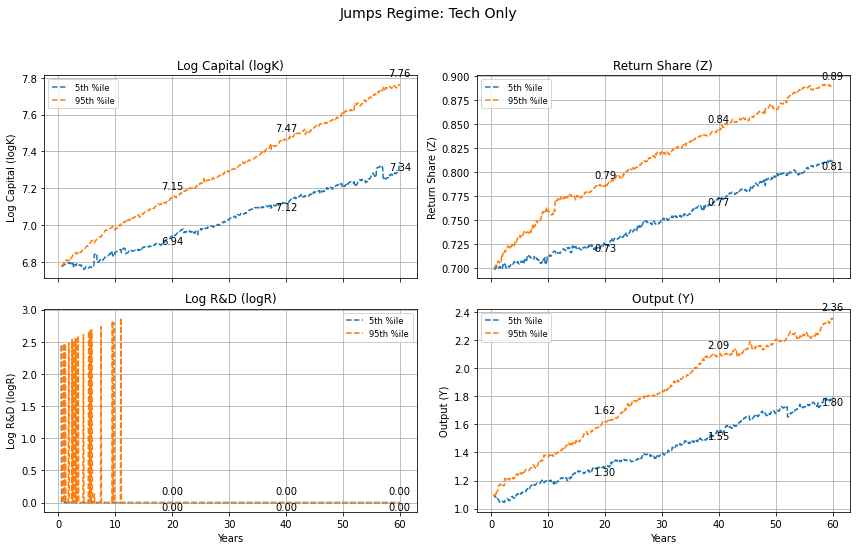


Regime: Both Jumps | Variable: Log Capital (logK)
  Year 20: insufficient data
  Year 40: 5th %ile = 7.1495, 95th %ile = 7.4804
  Year 60: 5th %ile = 7.2928, 95th %ile = 7.7585

Regime: Both Jumps | Variable: Return Share (Z)
  Year 20: insufficient data
  Year 40: 5th %ile = 0.7576, 95th %ile = 0.8531
  Year 60: 5th %ile = 0.8078, 95th %ile = 0.8785

Regime: Both Jumps | Variable: Log R&D (logR)
  Year 20: insufficient data
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: Both Jumps | Variable: Output (Y)
  Year 20: insufficient data
  Year 40: 5th %ile = 2.5141, 95th %ile = 2.7723
  Year 60: 5th %ile = 2.5000, 95th %ile = 3.1247


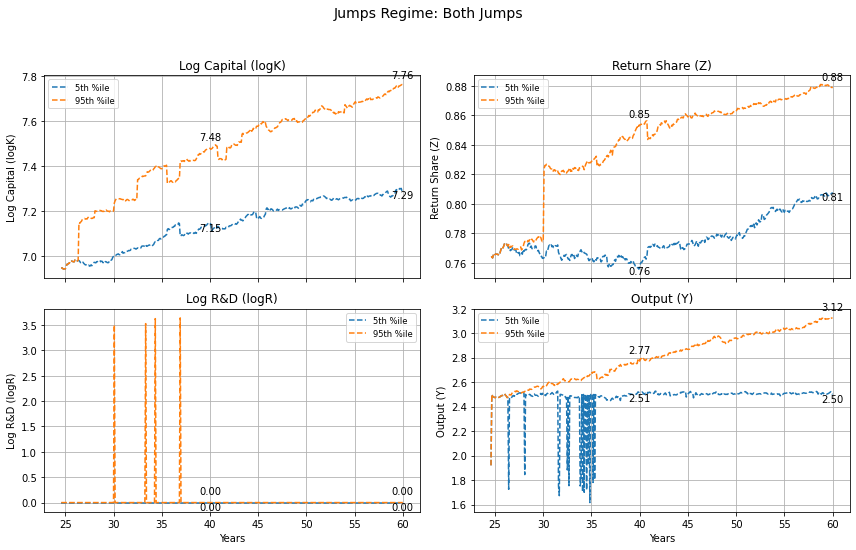

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---- EDIT THIS PATH to your actual simulation folder ----
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation_Y/paths_xi_148.4'

# Variables and their file prefixes
variables = {
    'Log Capital (logK)': 'logK_sim',
    'Return Share (Z)':   'R_array',
    'Log R&D (logR)':  'log_I_g_array',
    'Output (Y)':         'Y_array'
}

def load_and_concat(folder, prefix):
    """
    Find all .npy files in 'folder' starting with 'prefix', sort them,
    load and concatenate along the first axis.
    """
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        raise FileNotFoundError(f"No files for prefix '{prefix}' in {folder}")
    files.sort()
    arrays = [np.load(f) for f in files]
    return np.concatenate(arrays, axis=0)

# Load jump indicator arrays
tech_jump = load_and_concat(data_folder, 'tech_jump_array_')
damage_jump = load_and_concat(data_folder, 'damage_jump_array_')

# Ensure consistent time length
n_months = tech_jump.shape[1]

# Time axis in years (months 1 through n_months)
time_years = (np.arange(n_months) + 1) / 12.0

# Regime masks
regimes = {
    'No Jumps':         (tech_jump == 0) & (damage_jump == 0),
    'Damage Only':      (tech_jump == 0) & (damage_jump == 1),
    'Tech Only':        (tech_jump == 1) & (damage_jump == 0),
    'Both Jumps':       (tech_jump == 1) & (damage_jump == 1)
}

# Years at which to annotate percentiles
annot_years = [20, 40, 60]
# Corresponding indices in 0-based array
annot_idxs = [y * 12 - 1 for y in annot_years]

# Generate one figure per regime
for regime_label, mask in regimes.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()
    
    for ax, (var_label, prefix) in zip(axes, variables.items()):
        data = load_and_concat(data_folder, prefix)
        # Align to jump mask length
        if data.shape[1] > n_months:
            data = data[:, :n_months]
        
        # Compute 5th and 95th percentiles at each time step
        lower = np.full(n_months, np.nan)
        upper = np.full(n_months, np.nan)
        for t in range(n_months):
            values = data[mask[:, t], t]
            if values.size:
                lower[t] = np.percentile(values, 5)
                upper[t] = np.percentile(values, 95)
        
        
                # --- PRINT SELECTED‐YEAR PERCENTILES ---
        print(f"\nRegime: {regime_label} | Variable: {var_label}")
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                print(f"  Year {y:2d}: 5th %ile = {lower[idx]:.4f}, 95th %ile = {upper[idx]:.4f}")
            else:
                print(f"  Year {y:2d}: insufficient data")
        
        # Plot percentiles
        ax.plot(time_years, lower, linestyle='--', label='5th %ile')
        ax.plot(time_years, upper, linestyle='--', label='95th %ile')
        
        # Annotate at selected years
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                ax.annotate(f'{lower[idx]:.2f}', xy=(y, lower[idx]),
                            xytext=(0, -8), textcoords='offset points', ha='center')
            if not np.isnan(upper[idx]):
                ax.annotate(f'{upper[idx]:.2f}', xy=(y, upper[idx]),
                            xytext=(0,  8), textcoords='offset points', ha='center')
        
        ax.set_title(var_label)
        ax.set_ylabel(var_label)
        ax.grid(True)
        ax.legend(fontsize='small')
    
    # Final touches
    for ax in axes[2:]:
        ax.set_xlabel('Years')
    fig.suptitle(f'Jumps Regime: {regime_label}', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---- UPDATE THIS PATH to your actual simulation folder ----
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation_Y/paths_xi_0.1'

def load_and_concat(folder, prefix):
    """Load all .npy files in 'folder' starting with 'prefix'."""
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.startswith(prefix) and f.endswith('.npy')]
    files.sort()
    arrays = [np.load(f) for f in files]
    return np.concatenate(arrays, axis=0)

# Load jump indicator arrays
tech_jump = load_and_concat(data_folder, 'tech_jump_array_')
damage_jump = load_and_concat(data_folder, 'damage_jump_array_')

# Total number of paths and time steps
n_paths, n_months = tech_jump.shape

# Time axis in years
time_years = (np.arange(n_months) + 1) / 12.0

# Define regimes and compute percentages
regimes = {
    'No Jumps':    (tech_jump == 0) & (damage_jump == 0),
    'Damage Only': (tech_jump == 0) & (damage_jump == 1),
    'Tech Only':   (tech_jump == 1) & (damage_jump == 0),
    'Both Jumps':  (tech_jump == 1) & (damage_jump == 1),
}
percentages = {label: mask.sum(axis=0) / n_paths * 100 for label, mask in regimes.items()}

# Stackplot of regime shares
regime_labels = list(regimes.keys())

regime_labels = [ 'Both Jumps', 'Tech Only', 'Damage Only','No Jumps']
shares = [percentages[label] for label in regime_labels]

plt.figure(figsize=(10, 6))
plt.stackplot(time_years, *shares, labels=regime_labels, alpha=0.8)
plt.xlabel('Years')
plt.ylabel('Percentage of Paths (%)')
plt.title('Stacked Area: Share of Paths by Jump Regime Over Time')

# Annotate percentages at years 20, 40, 60
annot_years = [20, 40, 60]
annot_idxs  = [y * 12 - 1 for y in annot_years]  # zero-based month index
for y, idx in zip(annot_years, annot_idxs):
    cumulative = 0
    for label in regime_labels:
        h = percentages[label][idx]
        y_pos = cumulative + h / 2
        plt.text(y, y_pos, f"{h:.1f}%", ha='center', va='center')
        cumulative += h

plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation_Y/paths_xi_0.1'

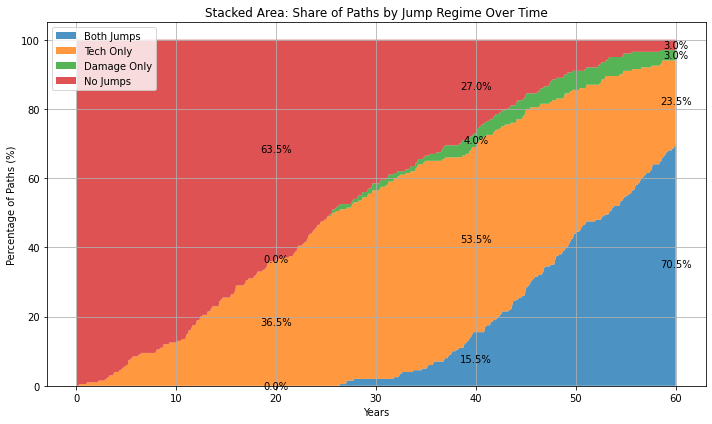

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---- UPDATE THIS PATH to your actual simulation folder ----
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation_Y/paths_xi_0.3'

def load_and_concat(folder, prefix):
    """Load all .npy files in 'folder' starting with 'prefix'."""
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.startswith(prefix) and f.endswith('.npy')]
    files.sort()
    arrays = [np.load(f) for f in files]
    return np.concatenate(arrays, axis=0)

# Load jump indicator arrays
tech_jump = load_and_concat(data_folder, 'tech_jump_array_')
damage_jump = load_and_concat(data_folder, 'damage_jump_array_')

# Total number of paths and time steps
n_paths, n_months = tech_jump.shape

# Time axis in years
time_years = (np.arange(n_months) + 1) / 12.0

# Define regimes and compute percentages
regimes = {
    'No Jumps':    (tech_jump == 0) & (damage_jump == 0),
    'Damage Only': (tech_jump == 0) & (damage_jump == 1),
    'Tech Only':   (tech_jump == 1) & (damage_jump == 0),
    'Both Jumps':  (tech_jump == 1) & (damage_jump == 1),
}
percentages = {label: mask.sum(axis=0) / n_paths * 100 for label, mask in regimes.items()}

# Stackplot of regime shares
regime_labels = list(regimes.keys())

regime_labels = [ 'Both Jumps', 'Tech Only', 'Damage Only','No Jumps']
shares = [percentages[label] for label in regime_labels]

plt.figure(figsize=(10, 6))
plt.stackplot(time_years, *shares, labels=regime_labels, alpha=0.8)
plt.xlabel('Years')
plt.ylabel('Percentage of Paths (%)')
plt.title('Stacked Area: Share of Paths by Jump Regime Over Time')

# Annotate percentages at years 20, 40, 60
annot_years = [20, 40, 60]
annot_idxs  = [y * 12 - 1 for y in annot_years]  # zero-based month index
for y, idx in zip(annot_years, annot_idxs):
    cumulative = 0
    for label in regime_labels:
        h = percentages[label][idx]
        y_pos = cumulative + h / 2
        plt.text(y, y_pos, f"{h:.1f}%", ha='center', va='center')
        cumulative += h

plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

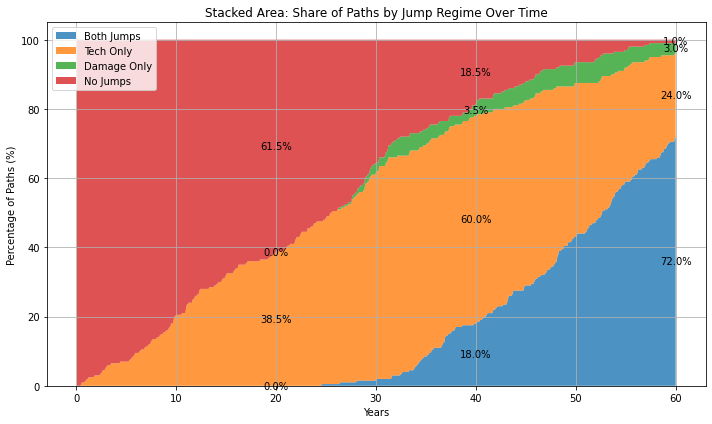

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---- UPDATE THIS PATH to your actual simulation folder ----
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation_Y/paths_xi_148.4'

def load_and_concat(folder, prefix):
    """Load all .npy files in 'folder' starting with 'prefix'."""
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.startswith(prefix) and f.endswith('.npy')]
    files.sort()
    arrays = [np.load(f) for f in files]
    return np.concatenate(arrays, axis=0)

# Load jump indicator arrays
tech_jump = load_and_concat(data_folder, 'tech_jump_array_')
damage_jump = load_and_concat(data_folder, 'damage_jump_array_')

# Total number of paths and time steps
n_paths, n_months = tech_jump.shape

# Time axis in years
time_years = (np.arange(n_months) + 1) / 12.0

# Define regimes and compute percentages
regimes = {
    'No Jumps':    (tech_jump == 0) & (damage_jump == 0),
    'Damage Only': (tech_jump == 0) & (damage_jump == 1),
    'Tech Only':   (tech_jump == 1) & (damage_jump == 0),
    'Both Jumps':  (tech_jump == 1) & (damage_jump == 1),
}
percentages = {label: mask.sum(axis=0) / n_paths * 100 for label, mask in regimes.items()}

# Stackplot of regime shares
regime_labels = list(regimes.keys())

regime_labels = [ 'Both Jumps', 'Tech Only', 'Damage Only','No Jumps']
shares = [percentages[label] for label in regime_labels]

plt.figure(figsize=(10, 6))
plt.stackplot(time_years, *shares, labels=regime_labels, alpha=0.8)
plt.xlabel('Years')
plt.ylabel('Percentage of Paths (%)')
plt.title('Stacked Area: Share of Paths by Jump Regime Over Time')

# Annotate percentages at years 20, 40, 60
annot_years = [20, 40, 60]
annot_idxs  = [y * 12 - 1 for y in annot_years]  # zero-based month index
for y, idx in zip(annot_years, annot_idxs):
    cumulative = 0
    for label in regime_labels:
        h = percentages[label][idx]
        y_pos = cumulative + h / 2
        plt.text(y, y_pos, f"{h:.1f}%", ha='center', va='center')
        cumulative += h

plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

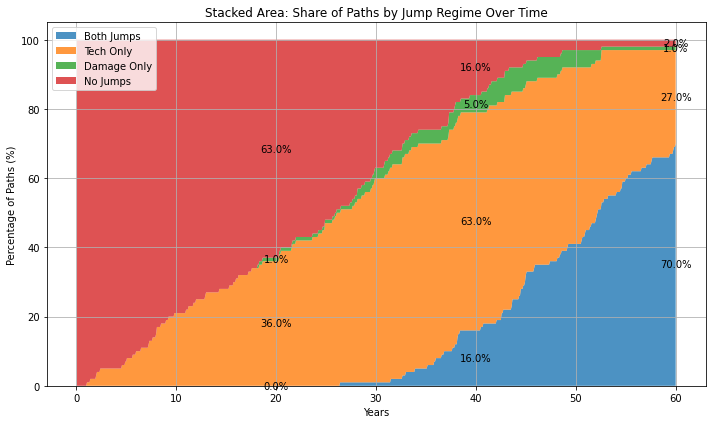

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---- UPDATE THIS PATH to your actual simulation folder ----
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation_New/paths_xi_0.075'

def load_and_concat(folder, prefix):
    """Load all .npy files in 'folder' starting with 'prefix'."""
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.startswith(prefix) and f.endswith('.npy')]
    files.sort()
    arrays = [np.load(f) for f in files]
    return np.concatenate(arrays, axis=0)

# Load jump indicator arrays
tech_jump = load_and_concat(data_folder, 'tech_jump_array_')
damage_jump = load_and_concat(data_folder, 'damage_jump_array_')

# Total number of paths and time steps
n_paths, n_months = tech_jump.shape

# Time axis in years
time_years = (np.arange(n_months) + 1) / 12.0

# Define regimes and compute percentages
regimes = {
    'No Jumps':    (tech_jump == 0) & (damage_jump == 0),
    'Damage Only': (tech_jump == 0) & (damage_jump == 1),
    'Tech Only':   (tech_jump == 1) & (damage_jump == 0),
    'Both Jumps':  (tech_jump == 1) & (damage_jump == 1),
}
percentages = {label: mask.sum(axis=0) / n_paths * 100 for label, mask in regimes.items()}

# Stackplot of regime shares
regime_labels = list(regimes.keys())

regime_labels = [ 'Both Jumps', 'Tech Only', 'Damage Only','No Jumps']
shares = [percentages[label] for label in regime_labels]

plt.figure(figsize=(10, 6))
plt.stackplot(time_years, *shares, labels=regime_labels, alpha=0.8)
plt.xlabel('Years')
plt.ylabel('Percentage of Paths (%)')
plt.title('Stacked Area: Share of Paths by Jump Regime Over Time')

# Annotate percentages at years 20, 40, 60
annot_years = [20, 40, 60]
annot_idxs  = [y * 12 - 1 for y in annot_years]  # zero-based month index
for y, idx in zip(annot_years, annot_idxs):
    cumulative = 0
    for label in regime_labels:
        h = percentages[label][idx]
        y_pos = cumulative + h / 2
        plt.text(y, y_pos, f"{h:.1f}%", ha='center', va='center')
        cumulative += h

plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## New simu



Regime: No Jumps | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8981, 95th %ile = 7.0651
  Year 40: 5th %ile = 7.0119, 95th %ile = 7.3351
  Year 60: 5th %ile = 7.1677, 95th %ile = 7.3360

Regime: No Jumps | Variable: Return Share (Z)
  Year 20: 5th %ile = 0.7242, 95th %ile = 0.7778
  Year 40: 5th %ile = 0.7644, 95th %ile = 0.8353
  Year 60: 5th %ile = 0.7913, 95th %ile = 0.8397

Regime: No Jumps | Variable: Log R&D (logR)
  Year 20: 5th %ile = 3.0166, 95th %ile = 3.1051
  Year 40: 5th %ile = 3.4620, 95th %ile = 3.5819
  Year 60: 5th %ile = 3.7802, 95th %ile = 3.9154

Regime: No Jumps | Variable: Output (Y)
  Year 20: 5th %ile = 1.3313, 95th %ile = 1.6390
  Year 40: 5th %ile = 1.6814, 95th %ile = 1.9741
  Year 60: 5th %ile = 1.7574, 95th %ile = 2.1756


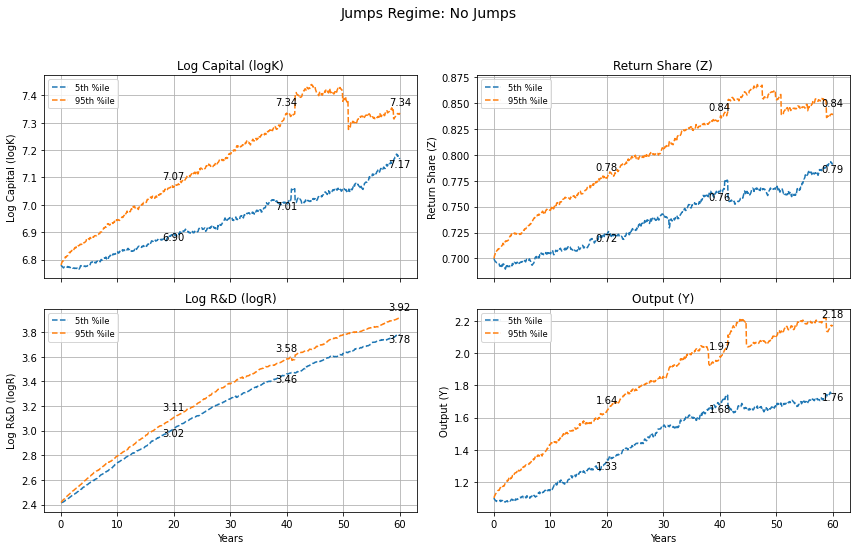


Regime: Damage Only | Variable: Log Capital (logK)
  Year 20: insufficient data
  Year 40: 5th %ile = 7.0819, 95th %ile = 7.2975
  Year 60: 5th %ile = 7.3155, 95th %ile = 7.4892

Regime: Damage Only | Variable: Return Share (Z)
  Year 20: insufficient data
  Year 40: 5th %ile = 0.7827, 95th %ile = 0.8301
  Year 60: 5th %ile = 0.8161, 95th %ile = 0.8814

Regime: Damage Only | Variable: Log R&D (logR)
  Year 20: insufficient data
  Year 40: 5th %ile = 3.4816, 95th %ile = 3.6170
  Year 60: 5th %ile = 3.8198, 95th %ile = 3.9093

Regime: Damage Only | Variable: Output (Y)
  Year 20: insufficient data
  Year 40: 5th %ile = 2.4624, 95th %ile = 2.6448
  Year 60: 5th %ile = 2.5241, 95th %ile = 2.9551


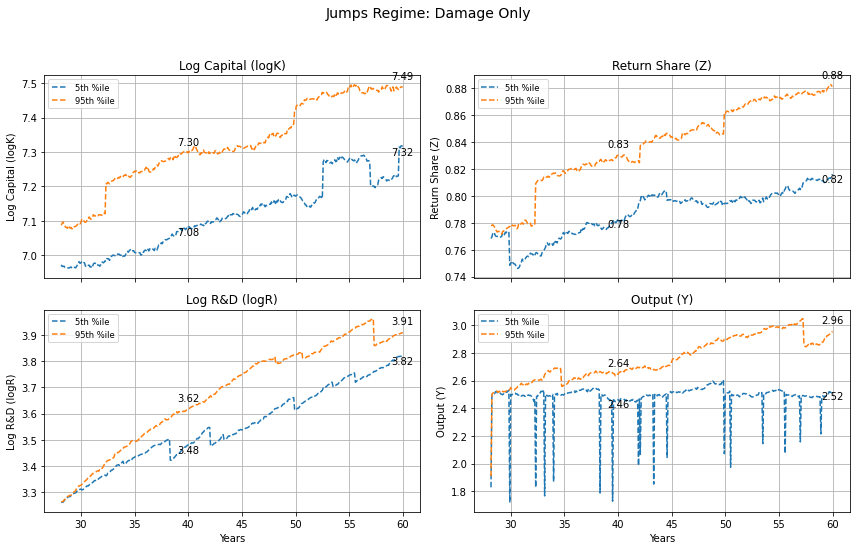


Regime: Tech Only | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.9303, 95th %ile = 7.1120
  Year 40: 5th %ile = 7.0608, 95th %ile = 7.4496
  Year 60: 5th %ile = 7.3195, 95th %ile = 7.8036

Regime: Tech Only | Variable: Return Share (Z)
  Year 20: 5th %ile = 0.7207, 95th %ile = 0.7751
  Year 40: 5th %ile = 0.7590, 95th %ile = 0.8408
  Year 60: 5th %ile = 0.8037, 95th %ile = 0.9007

Regime: Tech Only | Variable: Log R&D (logR)
  Year 20: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: Tech Only | Variable: Output (Y)
  Year 20: 5th %ile = 1.2725, 95th %ile = 1.6590
  Year 40: 5th %ile = 1.6188, 95th %ile = 2.1146
  Year 60: 5th %ile = 1.4395, 95th %ile = 2.3658


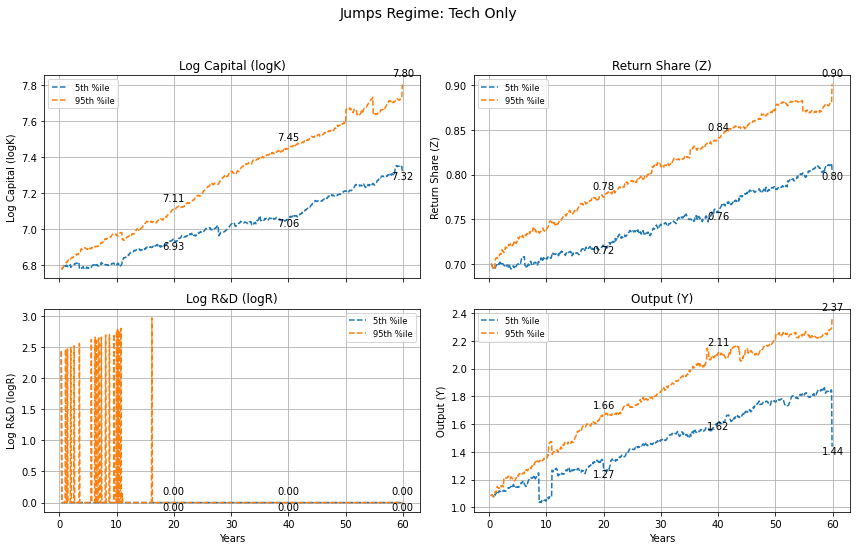


Regime: Both Jumps | Variable: Log Capital (logK)
  Year 20: insufficient data
  Year 40: 5th %ile = 7.1781, 95th %ile = 7.4503
  Year 60: 5th %ile = 7.2765, 95th %ile = 7.7381

Regime: Both Jumps | Variable: Return Share (Z)
  Year 20: insufficient data
  Year 40: 5th %ile = 0.7846, 95th %ile = 0.8168
  Year 60: 5th %ile = 0.7980, 95th %ile = 0.8808

Regime: Both Jumps | Variable: Log R&D (logR)
  Year 20: insufficient data
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: Both Jumps | Variable: Output (Y)
  Year 20: insufficient data
  Year 40: 5th %ile = 2.5000, 95th %ile = 2.7629
  Year 60: 5th %ile = 2.5194, 95th %ile = 3.1749


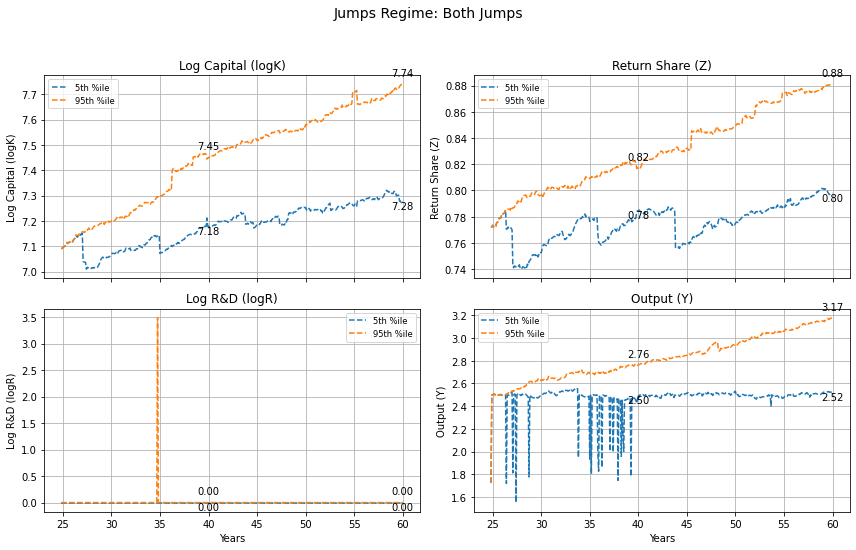

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---- EDIT THIS PATH to your actual simulation folder ----
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation_New/paths_xi_0.075'

# Variables and their file prefixes
variables = {
    'Log Capital (logK)': 'logK_sim',
    'Return Share (Z)':   'R_array',
    'Log R&D (logR)':  'log_I_g_array',
    'Output (Y)':         'Y_array'
}

def load_and_concat(folder, prefix):
    """
    Find all .npy files in 'folder' starting with 'prefix', sort them,
    load and concatenate along the first axis.
    """
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        raise FileNotFoundError(f"No files for prefix '{prefix}' in {folder}")
    files.sort()
    arrays = [np.load(f) for f in files]
    return np.concatenate(arrays, axis=0)

# Load jump indicator arrays
tech_jump = load_and_concat(data_folder, 'tech_jump_array_')
damage_jump = load_and_concat(data_folder, 'damage_jump_array_')

# Ensure consistent time length
n_months = tech_jump.shape[1]

# Time axis in years (months 1 through n_months)
time_years = (np.arange(n_months) + 1) / 12.0

# Regime masks
regimes = {
    'No Jumps':         (tech_jump == 0) & (damage_jump == 0),
    'Damage Only':      (tech_jump == 0) & (damage_jump == 1),
    'Tech Only':        (tech_jump == 1) & (damage_jump == 0),
    'Both Jumps':       (tech_jump == 1) & (damage_jump == 1)
}

# Years at which to annotate percentiles
annot_years = [20, 40, 60]
# Corresponding indices in 0-based array
annot_idxs = [y * 12 - 1 for y in annot_years]

# Generate one figure per regime
for regime_label, mask in regimes.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()
    
    for ax, (var_label, prefix) in zip(axes, variables.items()):
        data = load_and_concat(data_folder, prefix)
        # Align to jump mask length
        if data.shape[1] > n_months:
            data = data[:, :n_months]
        
        # Compute 5th and 95th percentiles at each time step
        lower = np.full(n_months, np.nan)
        upper = np.full(n_months, np.nan)
        for t in range(n_months):
            values = data[mask[:, t], t]
            if values.size:
                lower[t] = np.percentile(values, 5)
                upper[t] = np.percentile(values, 95)
        
        
                # --- PRINT SELECTED‐YEAR PERCENTILES ---
        print(f"\nRegime: {regime_label} | Variable: {var_label}")
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                print(f"  Year {y:2d}: 5th %ile = {lower[idx]:.4f}, 95th %ile = {upper[idx]:.4f}")
            else:
                print(f"  Year {y:2d}: insufficient data")
        
        # Plot percentiles
        ax.plot(time_years, lower, linestyle='--', label='5th %ile')
        ax.plot(time_years, upper, linestyle='--', label='95th %ile')
        
        # Annotate at selected years
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                ax.annotate(f'{lower[idx]:.2f}', xy=(y, lower[idx]),
                            xytext=(0, -8), textcoords='offset points', ha='center')
            if not np.isnan(upper[idx]):
                ax.annotate(f'{upper[idx]:.2f}', xy=(y, upper[idx]),
                            xytext=(0,  8), textcoords='offset points', ha='center')
        
        ax.set_title(var_label)
        ax.set_ylabel(var_label)
        ax.grid(True)
        ax.legend(fontsize='small')
    
    # Final touches
    for ax in axes[2:]:
        ax.set_xlabel('Years')
    fig.suptitle(f'Jumps Regime: {regime_label}', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



Regime: No Jumps | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.9138, 95th %ile = 7.0735
  Year 40: 5th %ile = 7.0644, 95th %ile = 7.2847
  Year 60: 5th %ile = 7.2384, 95th %ile = 7.2384

Regime: No Jumps | Variable: Return Share (Z)
  Year 20: 5th %ile = 0.7190, 95th %ile = 0.7752
  Year 40: 5th %ile = 0.7639, 95th %ile = 0.8286
  Year 60: 5th %ile = 0.8373, 95th %ile = 0.8373

Regime: No Jumps | Variable: Log R&D (logR)
  Year 20: 5th %ile = 3.0023, 95th %ile = 3.0849
  Year 40: 5th %ile = 3.4518, 95th %ile = 3.5614
  Year 60: 5th %ile = 3.7501, 95th %ile = 3.7501

Regime: No Jumps | Variable: Output (Y)
  Year 20: 5th %ile = 1.2512, 95th %ile = 1.6023
  Year 40: 5th %ile = 1.5454, 95th %ile = 1.9632
  Year 60: 5th %ile = 1.9637, 95th %ile = 1.9637


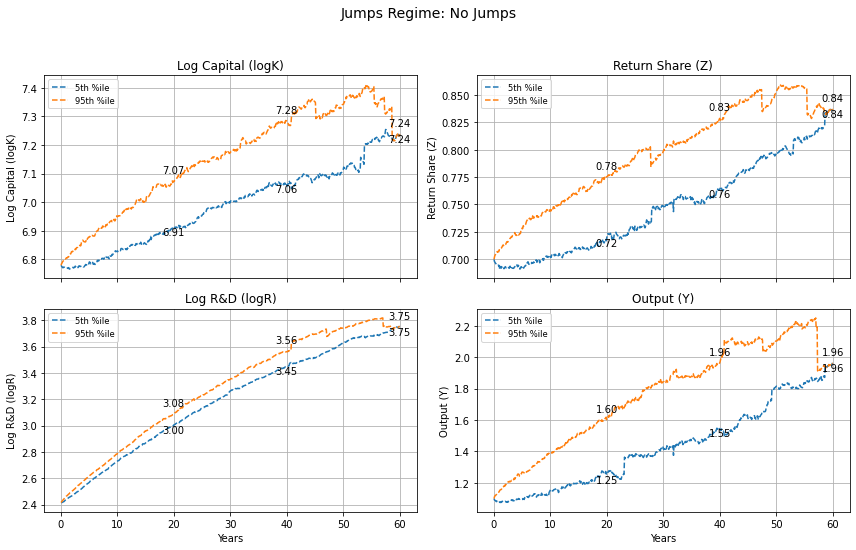


Regime: Damage Only | Variable: Log Capital (logK)
  Year 20: insufficient data
  Year 40: 5th %ile = 7.0387, 95th %ile = 7.2569
  Year 60: 5th %ile = 7.1656, 95th %ile = 7.5175

Regime: Damage Only | Variable: Return Share (Z)
  Year 20: insufficient data
  Year 40: 5th %ile = 0.7816, 95th %ile = 0.8366
  Year 60: 5th %ile = 0.8242, 95th %ile = 0.8714

Regime: Damage Only | Variable: Log R&D (logR)
  Year 20: insufficient data
  Year 40: 5th %ile = 3.4976, 95th %ile = 3.5658
  Year 60: 5th %ile = 3.7827, 95th %ile = 4.0433

Regime: Damage Only | Variable: Output (Y)
  Year 20: insufficient data
  Year 40: 5th %ile = 2.5483, 95th %ile = 2.7362
  Year 60: 5th %ile = 2.5202, 95th %ile = 3.0128


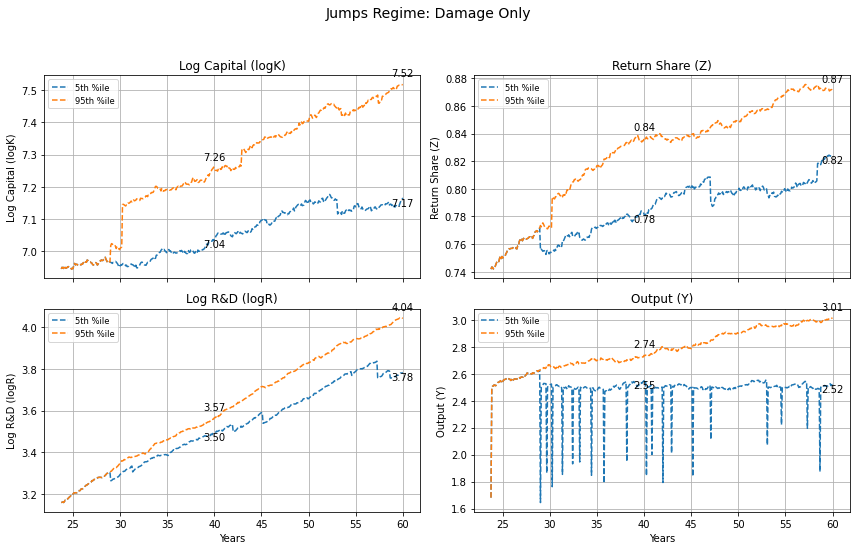


Regime: Tech Only | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.9306, 95th %ile = 7.1556
  Year 40: 5th %ile = 7.1442, 95th %ile = 7.5493
  Year 60: 5th %ile = 7.2549, 95th %ile = 7.8489

Regime: Tech Only | Variable: Return Share (Z)
  Year 20: 5th %ile = 0.7234, 95th %ile = 0.7863
  Year 40: 5th %ile = 0.7595, 95th %ile = 0.8419
  Year 60: 5th %ile = 0.8076, 95th %ile = 0.8963

Regime: Tech Only | Variable: Log R&D (logR)
  Year 20: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: Tech Only | Variable: Output (Y)
  Year 20: 5th %ile = 1.3331, 95th %ile = 1.6178
  Year 40: 5th %ile = 1.5623, 95th %ile = 2.1230
  Year 60: 5th %ile = 1.8670, 95th %ile = 2.5569


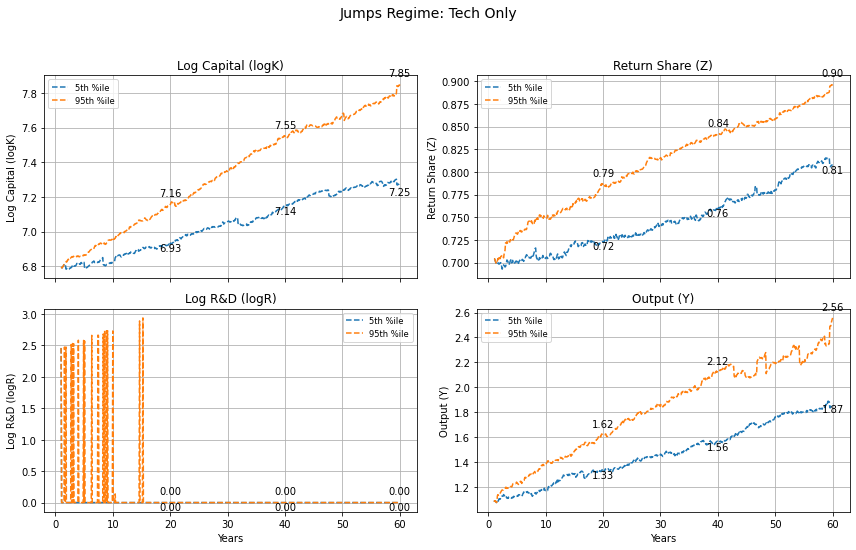


Regime: Both Jumps | Variable: Log Capital (logK)
  Year 20: insufficient data
  Year 40: 5th %ile = 7.1486, 95th %ile = 7.4672
  Year 60: 5th %ile = 7.3252, 95th %ile = 7.8086

Regime: Both Jumps | Variable: Return Share (Z)
  Year 20: insufficient data
  Year 40: 5th %ile = 0.7475, 95th %ile = 0.8357
  Year 60: 5th %ile = 0.7934, 95th %ile = 0.8760

Regime: Both Jumps | Variable: Log R&D (logR)
  Year 20: insufficient data
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: Both Jumps | Variable: Output (Y)
  Year 20: insufficient data
  Year 40: 5th %ile = 2.4974, 95th %ile = 2.9288
  Year 60: 5th %ile = 2.5489, 95th %ile = 3.2809


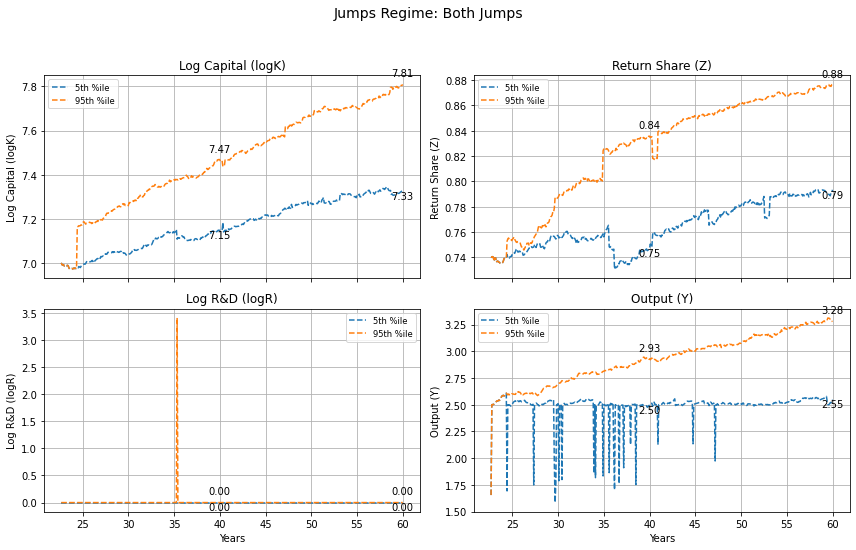

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---- EDIT THIS PATH to your actual simulation folder ----
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters_NewIntensity/Simulation_New/paths_xi_0.3'

# Variables and their file prefixes
variables = {
    'Log Capital (logK)': 'logK_sim',
    'Return Share (Z)':   'R_array',
    'Log R&D (logR)':  'log_I_g_array',
    'Output (Y)':         'Y_array'
}

def load_and_concat(folder, prefix):
    """
    Find all .npy files in 'folder' starting with 'prefix', sort them,
    load and concatenate along the first axis.
    """
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        raise FileNotFoundError(f"No files for prefix '{prefix}' in {folder}")
    files.sort()
    arrays = [np.load(f) for f in files]
    return np.concatenate(arrays, axis=0)

# Load jump indicator arrays
tech_jump = load_and_concat(data_folder, 'tech_jump_array_')
damage_jump = load_and_concat(data_folder, 'damage_jump_array_')

# Ensure consistent time length
n_months = tech_jump.shape[1]

# Time axis in years (months 1 through n_months)
time_years = (np.arange(n_months) + 1) / 12.0

# Regime masks
regimes = {
    'No Jumps':         (tech_jump == 0) & (damage_jump == 0),
    'Damage Only':      (tech_jump == 0) & (damage_jump == 1),
    'Tech Only':        (tech_jump == 1) & (damage_jump == 0),
    'Both Jumps':       (tech_jump == 1) & (damage_jump == 1)
}

# Years at which to annotate percentiles
annot_years = [20, 40, 60]
# Corresponding indices in 0-based array
annot_idxs = [y * 12 - 1 for y in annot_years]

# Generate one figure per regime
for regime_label, mask in regimes.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()
    
    for ax, (var_label, prefix) in zip(axes, variables.items()):
        data = load_and_concat(data_folder, prefix)
        # Align to jump mask length
        if data.shape[1] > n_months:
            data = data[:, :n_months]
        
        # Compute 5th and 95th percentiles at each time step
        lower = np.full(n_months, np.nan)
        upper = np.full(n_months, np.nan)
        for t in range(n_months):
            values = data[mask[:, t], t]
            if values.size:
                lower[t] = np.percentile(values, 5)
                upper[t] = np.percentile(values, 95)
        
        
                # --- PRINT SELECTED‐YEAR PERCENTILES ---
        print(f"\nRegime: {regime_label} | Variable: {var_label}")
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                print(f"  Year {y:2d}: 5th %ile = {lower[idx]:.4f}, 95th %ile = {upper[idx]:.4f}")
            else:
                print(f"  Year {y:2d}: insufficient data")
        
        # Plot percentiles
        ax.plot(time_years, lower, linestyle='--', label='5th %ile')
        ax.plot(time_years, upper, linestyle='--', label='95th %ile')
        
        # Annotate at selected years
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                ax.annotate(f'{lower[idx]:.2f}', xy=(y, lower[idx]),
                            xytext=(0, -8), textcoords='offset points', ha='center')
            if not np.isnan(upper[idx]):
                ax.annotate(f'{upper[idx]:.2f}', xy=(y, upper[idx]),
                            xytext=(0,  8), textcoords='offset points', ha='center')
        
        ax.set_title(var_label)
        ax.set_ylabel(var_label)
        ax.grid(True)
        ax.legend(fontsize='small')
    
    # Final touches
    for ax in axes[2:]:
        ax.set_xlabel('Years')
    fig.suptitle(f'Jumps Regime: {regime_label}', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


Regime: PreDamage–PreTech (0,0) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.7968, 95th %ile = 6.9027
  Year 40: 5th %ile = 6.8408, 95th %ile = 6.9929
  Year 60: 5th %ile = 6.8432, 95th %ile = 7.0724

Regime: PreDamage–PreTech (0,0) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.6893, 95th %ile = 0.7288
  Year 40: 5th %ile = 0.7031, 95th %ile = 0.7527
  Year 60: 5th %ile = 0.7121, 95th %ile = 0.7723

Regime: PreDamage–PreTech (0,0) | Variable: Log Research (logR)
  Year 20: 5th %ile = 3.1719, 95th %ile = 3.2645
  Year 40: 5th %ile = 3.6857, 95th %ile = 3.8249
  Year 60: 5th %ile = 4.0861, 95th %ile = 4.2138

Regime: PreDamage–PreTech (0,0) | Variable: Output (Y)
  Year 20: 5th %ile = 1.3395, 95th %ile = 1.6164
  Year 40: 5th %ile = 1.6598, 95th %ile = 2.0425
  Year 60: 5th %ile = 1.9685, 95th %ile = 2.2986

Regime: PreDamage–PreTech (0,0) | Variable: Tech Level A_g
  Year 20: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 6

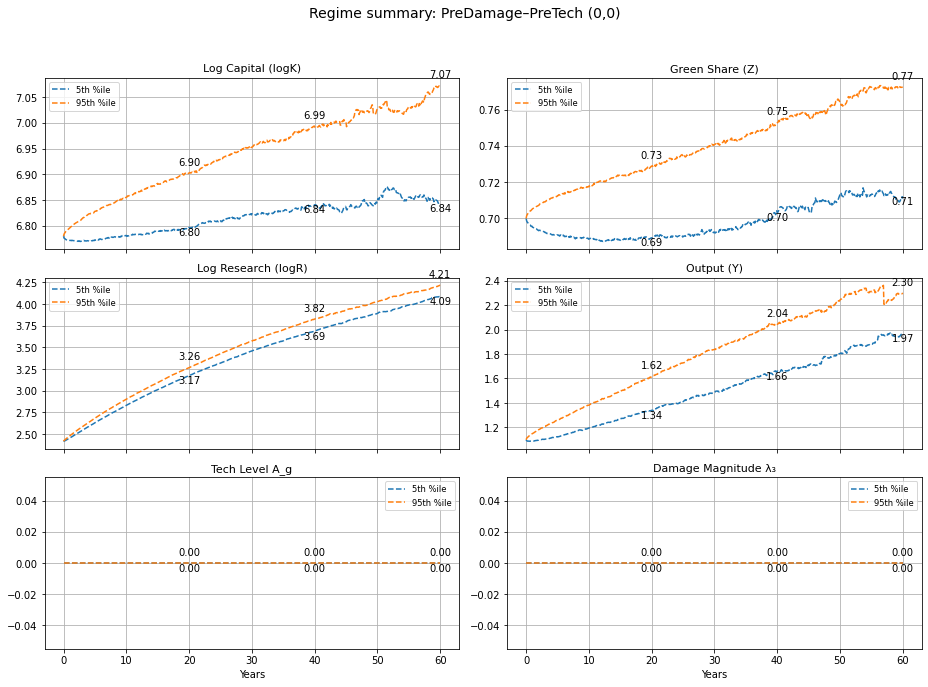


Regime: PostDamage–PreTech (0,1) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8595, 95th %ile = 6.8937
  Year 40: 5th %ile = 6.8487, 95th %ile = 6.9856
  Year 60: 5th %ile = 6.8730, 95th %ile = 7.0599

Regime: PostDamage–PreTech (0,1) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.7060, 95th %ile = 0.7087
  Year 40: 5th %ile = 0.6960, 95th %ile = 0.7452
  Year 60: 5th %ile = 0.7132, 95th %ile = 0.7755

Regime: PostDamage–PreTech (0,1) | Variable: Log Research (logR)
  Year 20: 5th %ile = 3.2300, 95th %ile = 3.2480
  Year 40: 5th %ile = 3.6854, 95th %ile = 3.8070
  Year 60: 5th %ile = 4.0546, 95th %ile = 4.1819

Regime: PostDamage–PreTech (0,1) | Variable: Output (Y)
  Year 20: 5th %ile = 2.5359, 95th %ile = 2.5489
  Year 40: 5th %ile = 2.5176, 95th %ile = 2.8270
  Year 60: 5th %ile = 2.5506, 95th %ile = 3.0638

Regime: PostDamage–PreTech (0,1) | Variable: Tech Level A_g
  Year 20: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Y

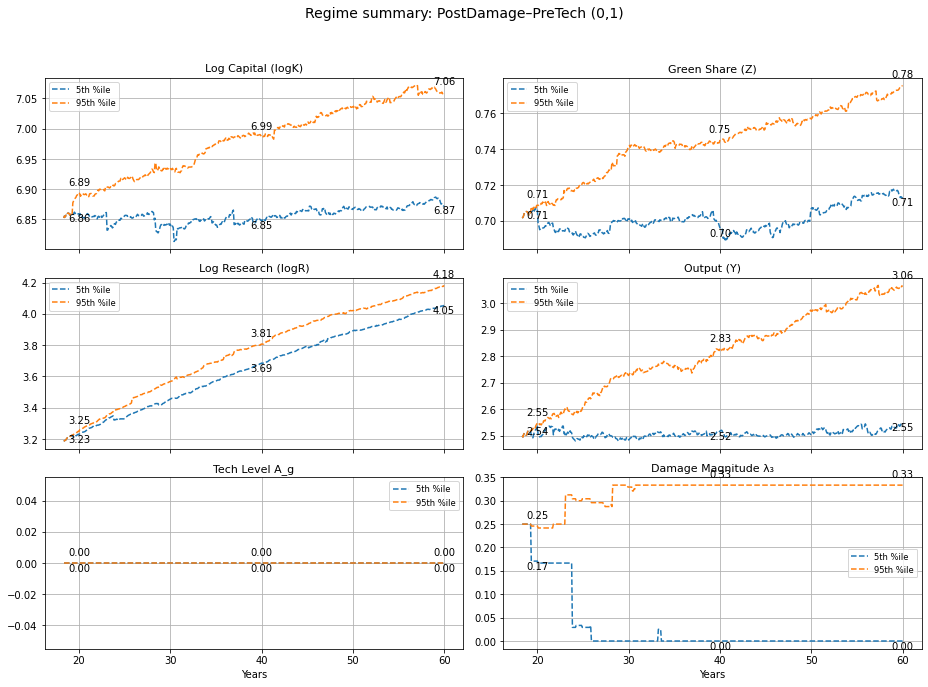


Regime: PreDamage–IntermTech (1,0) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8246, 95th %ile = 6.9656
  Year 40: 5th %ile = 6.8865, 95th %ile = 7.1235
  Year 60: 5th %ile = 6.9528, 95th %ile = 7.2794

Regime: PreDamage–IntermTech (1,0) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.7001, 95th %ile = 0.7431
  Year 40: 5th %ile = 0.7126, 95th %ile = 0.7737
  Year 60: 5th %ile = 0.7340, 95th %ile = 0.8075

Regime: PreDamage–IntermTech (1,0) | Variable: Log Research (logR)
  Year 20: 5th %ile = 3.1822, 95th %ile = 3.2754
  Year 40: 5th %ile = 3.7156, 95th %ile = 3.8479
  Year 60: 5th %ile = 4.1088, 95th %ile = 4.2715

Regime: PreDamage–IntermTech (1,0) | Variable: Output (Y)
  Year 20: 5th %ile = 1.3326, 95th %ile = 1.6061
  Year 40: 5th %ile = 1.6347, 95th %ile = 2.0226
  Year 60: 5th %ile = 1.8895, 95th %ile = 2.3675

Regime: PreDamage–IntermTech (1,0) | Variable: Tech Level A_g
  Year 20: 5th %ile = 0.1303, 95th %ile = 0.1303
  Year 40: 5th %ile = 0.1303, 95th %ile = 

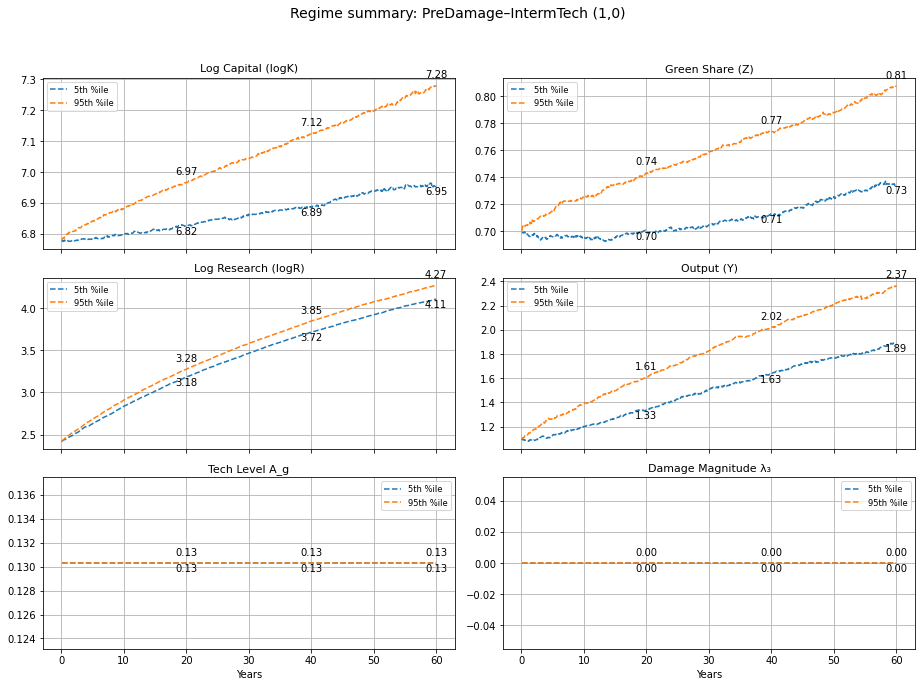


Regime: PostDamage–IntermTech (1,1) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8310, 95th %ile = 6.8633
  Year 40: 5th %ile = 6.9004, 95th %ile = 7.1227
  Year 60: 5th %ile = 6.9837, 95th %ile = 7.2739

Regime: PostDamage–IntermTech (1,1) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.7004, 95th %ile = 0.7273
  Year 40: 5th %ile = 0.7118, 95th %ile = 0.7737
  Year 60: 5th %ile = 0.7321, 95th %ile = 0.8037

Regime: PostDamage–IntermTech (1,1) | Variable: Log Research (logR)
  Year 20: 5th %ile = 3.1865, 95th %ile = 3.2264
  Year 40: 5th %ile = 3.6991, 95th %ile = 3.8357
  Year 60: 5th %ile = 4.0799, 95th %ile = 4.2524

Regime: PostDamage–IntermTech (1,1) | Variable: Output (Y)
  Year 20: 5th %ile = 2.5068, 95th %ile = 2.5274
  Year 40: 5th %ile = 2.5031, 95th %ile = 2.8430
  Year 60: 5th %ile = 2.5512, 95th %ile = 3.1501

Regime: PostDamage–IntermTech (1,1) | Variable: Tech Level A_g
  Year 20: 5th %ile = 0.1303, 95th %ile = 0.1303
  Year 40: 5th %ile = 0.1303, 95th %i

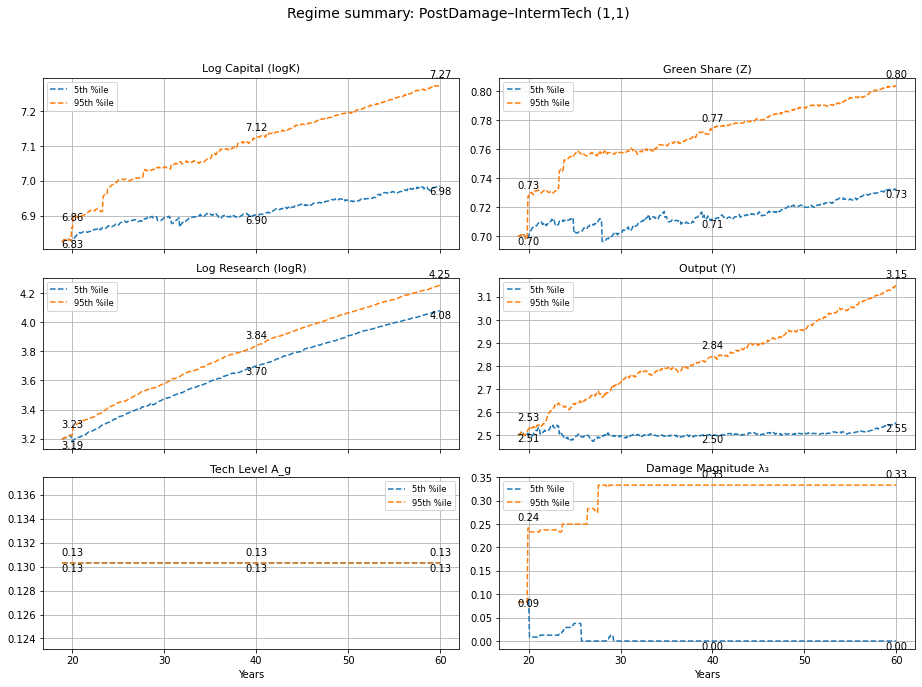


Regime: PreDamage–PostTech (2,0) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8778, 95th %ile = 7.0682
  Year 40: 5th %ile = 6.9538, 95th %ile = 7.3973
  Year 60: 5th %ile = 7.1145, 95th %ile = 7.5925

Regime: PreDamage–PostTech (2,0) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.7194, 95th %ile = 0.7932
  Year 40: 5th %ile = 0.7349, 95th %ile = 0.8594
  Year 60: 5th %ile = 0.7737, 95th %ile = 0.8949

Regime: PreDamage–PostTech (2,0) | Variable: Log Research (logR)
  Year 20: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: PreDamage–PostTech (2,0) | Variable: Output (Y)
  Year 20: 5th %ile = 1.3069, 95th %ile = 1.5335
  Year 40: 5th %ile = 1.6543, 95th %ile = 2.0648
  Year 60: 5th %ile = 1.9290, 95th %ile = 2.3036

Regime: PreDamage–PostTech (2,0) | Variable: Tech Level A_g
  Year 20: 5th %ile = 0.1567, 95th %ile = 0.1567
  Year 40: 5th %ile = 0.1567, 95th %ile = 0.1567
  Y

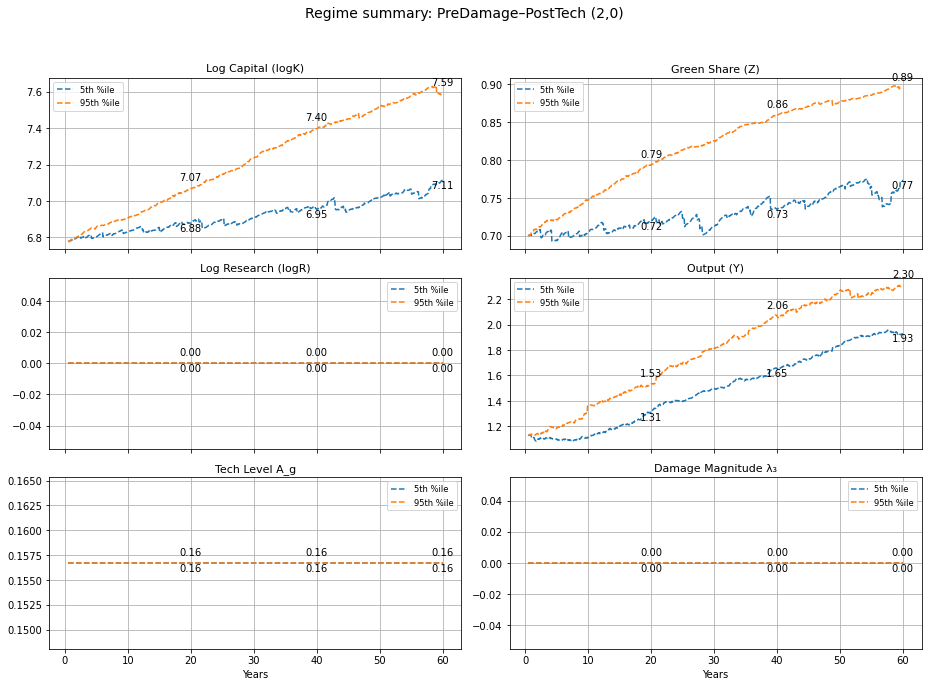


Regime: PostDamage–PostTech (2,1) | Variable: Log Capital (logK)
  Year 20: insufficient data in this regime at that time
  Year 40: 5th %ile = 7.0360, 95th %ile = 7.3241
  Year 60: 5th %ile = 7.0535, 95th %ile = 7.6583

Regime: PostDamage–PostTech (2,1) | Variable: Green Share (Z)
  Year 20: insufficient data in this regime at that time
  Year 40: 5th %ile = 0.7628, 95th %ile = 0.8524
  Year 60: 5th %ile = 0.7643, 95th %ile = 0.9030

Regime: PostDamage–PostTech (2,1) | Variable: Log Research (logR)
  Year 20: insufficient data in this regime at that time
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: PostDamage–PostTech (2,1) | Variable: Output (Y)
  Year 20: insufficient data in this regime at that time
  Year 40: 5th %ile = 2.5043, 95th %ile = 2.7231
  Year 60: 5th %ile = 2.5093, 95th %ile = 3.0113

Regime: PostDamage–PostTech (2,1) | Variable: Tech Level A_g
  Year 20: insufficient data in this regime at that time
  Year 

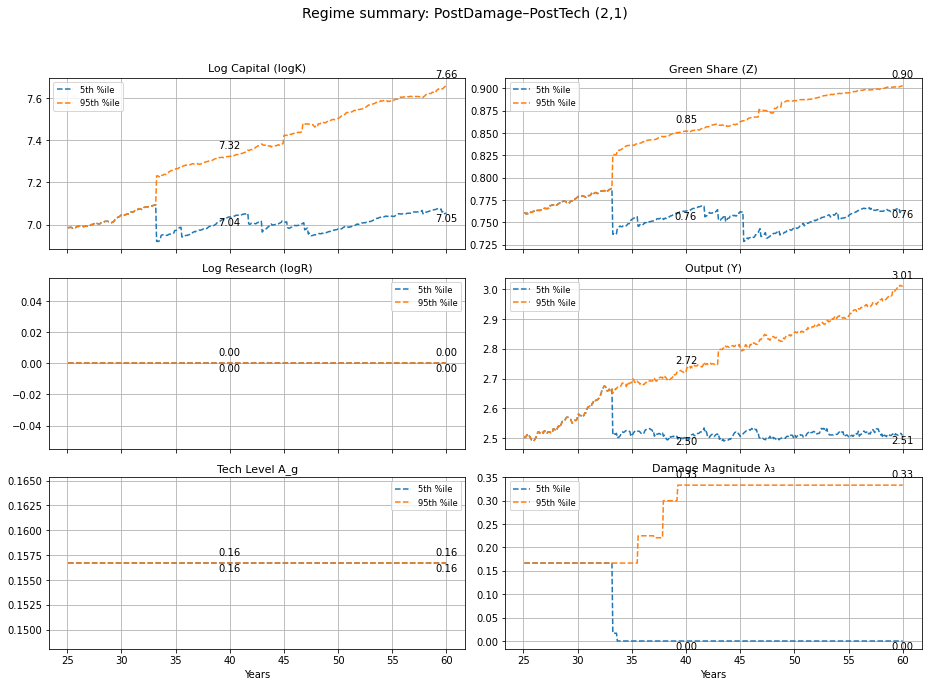

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ====== EDIT THIS to your simulation folder ======
data_folder = '/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/SimulationResults/paths_ξ_0.1'

# Variables to summarize (title -> file prefix)
variables = {
    'Log Capital (logK)':      'logK_sim_',
    'Green Share (Z)':         'Z_array_',
    'Log Research (logR)':     'logR_array_',
    'Output (Y)':              'Y_array_',
    'Tech Level A_g':          'A_g_array_',
    'Damage Magnitude λ₃':     'gamma3_array_',
}

def load_and_concat(folder, prefix):
    """
    Load all .npy files in 'folder' whose names start with 'prefix',
    sort them, and concatenate on axis=0 (paths).
    """
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        raise FileNotFoundError(f"No files for prefix '{prefix}' in {folder}")
    files.sort()
    arrays = [np.load(f) for f in files]
    # Ensure 2D arrays [n_paths, T+1]
    arrays = [a if a.ndim == 2 else np.atleast_2d(a) for a in arrays]
    return np.concatenate(arrays, axis=0)

# --- Load state arrays first (for masks/time axis) ---
tech_state = load_and_concat(data_folder, 'tech_state_array_')   # values in {0,1,2}
damage_state = load_and_concat(data_folder, 'damage_state_array_') # values in {0,1}

# Align time length to states
n_paths, n_steps = tech_state.shape
time_years = np.arange(n_steps) / 12.0   # includes t=0 at year 0

# Six-regime masks (shape: [n_paths, n_steps])
regimes = {
    'PreDamage–PreTech (0,0)':     (tech_state == 0) & (damage_state == 0),
    'PostDamage–PreTech (0,1)':    (tech_state == 0) & (damage_state == 1),
    'PreDamage–IntermTech (1,0)':  (tech_state == 1) & (damage_state == 0),
    'PostDamage–IntermTech (1,1)': (tech_state == 1) & (damage_state == 1),
    'PreDamage–PostTech (2,0)':    (tech_state == 2) & (damage_state == 0),
    'PostDamage–PostTech (2,1)':   (tech_state == 2) & (damage_state == 1),
}

# years to print percentiles for (indices at exact end-of-year)
annot_years = [20, 40, 60]
annot_idxs = [y*12 for y in annot_years if y*12 < n_steps]

# --- Load all variable arrays ---
data_arrays = {}
for label, prefix in variables.items():
    arr = load_and_concat(data_folder, prefix)
    # Trim/align time dimension if needed
    if arr.shape[1] > n_steps:
        arr = arr[:, :n_steps]
    elif arr.shape[1] < n_steps:
        # If shorter, trim states to match (rare)
        tech_state = tech_state[:, :arr.shape[1]]
        damage_state = damage_state[:, :arr.shape[1]]
        n_steps = arr.shape[1]
        time_years = np.arange(n_steps) / 12.0
        annot_idxs = [y*12 for y in annot_years if y*12 < n_steps]
        # Recompute masks with new length
        regimes = {
            'PreDamage–PreTech (0,0)':     (tech_state == 0) & (damage_state == 0),
            'PostDamage–PreTech (0,1)':    (tech_state == 0) & (damage_state == 1),
            'PreDamage–IntermTech (1,0)':  (tech_state == 1) & (damage_state == 0),
            'PostDamage–IntermTech (1,1)': (tech_state == 1) & (damage_state == 1),
            'PreDamage–PostTech (2,0)':    (tech_state == 2) & (damage_state == 0),
            'PostDamage–PostTech (2,1)':   (tech_state == 2) & (damage_state == 1),
        }
    data_arrays[label] = arr

# --- Make one figure per regime (3x2 panels to show 6 variables) ---
labels_in_order = list(variables.keys())
nrows, ncols = 3, 2

for regime_label, mask in regimes.items():
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 10), sharex=True)
    axes = axes.flatten()

    for ax, var_label in zip(axes, labels_in_order):
        arr = data_arrays[var_label]   # shape [n_paths_total, n_steps]
        lower = np.full(n_steps, np.nan)
        upper = np.full(n_steps, np.nan)

        # compute 5th/95th across paths that are in this regime at time t
        for t in range(n_steps):
            sel = mask[:, t]
            if sel.any():
                vals = arr[sel, t]
                lower[t] = np.percentile(vals, 5)
                upper[t] = np.percentile(vals, 95)

        # --- Print selected-year percentiles ---
        print(f"\nRegime: {regime_label} | Variable: {var_label}")
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                print(f"  Year {y:2d}: 5th %ile = {lower[idx]:.4f}, 95th %ile = {upper[idx]:.4f}")
            else:
                print(f"  Year {y:2d}: insufficient data in this regime at that time")

        # Plot percentile bands (dashed lines)
        ax.plot(time_years, lower, linestyle='--', label='5th %ile')
        ax.plot(time_years, upper, linestyle='--', label='95th %ile')

        # Annotate the printed years
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                ax.annotate(f'{lower[idx]:.2f}', xy=(y, lower[idx]),
                            xytext=(0, -8), textcoords='offset points', ha='center')
            if not np.isnan(upper[idx]):
                ax.annotate(f'{upper[idx]:.2f}', xy=(y, upper[idx]),
                            xytext=(0,  8), textcoords='offset points', ha='center')

        ax.set_title(var_label, fontsize=11)
        ax.grid(True)
        ax.legend(fontsize='small')

    # labels & layout
    for ax in axes[-ncols:]:
        ax.set_xlabel('Years')
    fig.suptitle(f'Regime summary: {regime_label}', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



Regime: PreDamage–PreTech (0,0) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8009, 95th %ile = 6.9131
  Year 40: 5th %ile = 6.8443, 95th %ile = 6.9918
  Year 60: 5th %ile = 6.8686, 95th %ile = 7.0572

Regime: PreDamage–PreTech (0,0) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.6902, 95th %ile = 0.7285
  Year 40: 5th %ile = 0.7009, 95th %ile = 0.7541
  Year 60: 5th %ile = 0.7261, 95th %ile = 0.7775

Regime: PreDamage–PreTech (0,0) | Variable: Log Research (logR)
  Year 20: 5th %ile = 3.1348, 95th %ile = 3.2280
  Year 40: 5th %ile = 3.6457, 95th %ile = 3.7601
  Year 60: 5th %ile = 4.0132, 95th %ile = 4.1198

Regime: PreDamage–PreTech (0,0) | Variable: Output (Y)
  Year 20: 5th %ile = 1.3380, 95th %ile = 1.6207
  Year 40: 5th %ile = 1.6091, 95th %ile = 2.0465
  Year 60: 5th %ile = 1.8871, 95th %ile = 2.3681


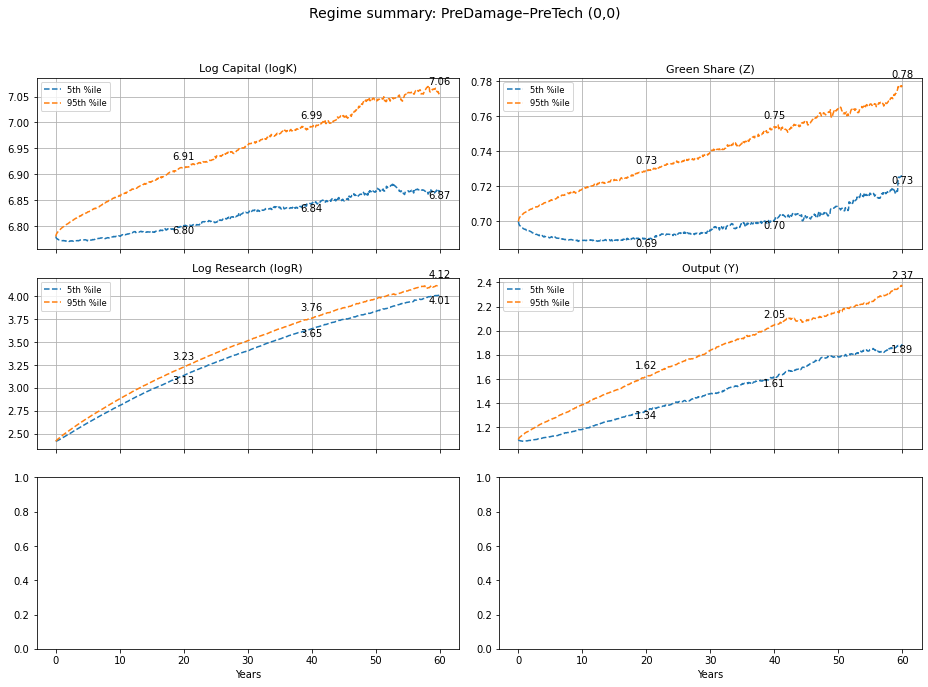


Regime: PostDamage–PreTech (0,1) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8621, 95th %ile = 6.8621
  Year 40: 5th %ile = 6.8583, 95th %ile = 7.0122
  Year 60: 5th %ile = 6.8815, 95th %ile = 7.0727

Regime: PostDamage–PreTech (0,1) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.7069, 95th %ile = 0.7069
  Year 40: 5th %ile = 0.7040, 95th %ile = 0.7527
  Year 60: 5th %ile = 0.7122, 95th %ile = 0.7765

Regime: PostDamage–PreTech (0,1) | Variable: Log Research (logR)
  Year 20: 5th %ile = 3.2232, 95th %ile = 3.2232
  Year 40: 5th %ile = 3.6476, 95th %ile = 3.7602
  Year 60: 5th %ile = 4.0127, 95th %ile = 4.1455

Regime: PostDamage–PreTech (0,1) | Variable: Output (Y)
  Year 20: 5th %ile = 2.4956, 95th %ile = 2.4956
  Year 40: 5th %ile = 2.5044, 95th %ile = 2.7517
  Year 60: 5th %ile = 2.5298, 95th %ile = 3.1577


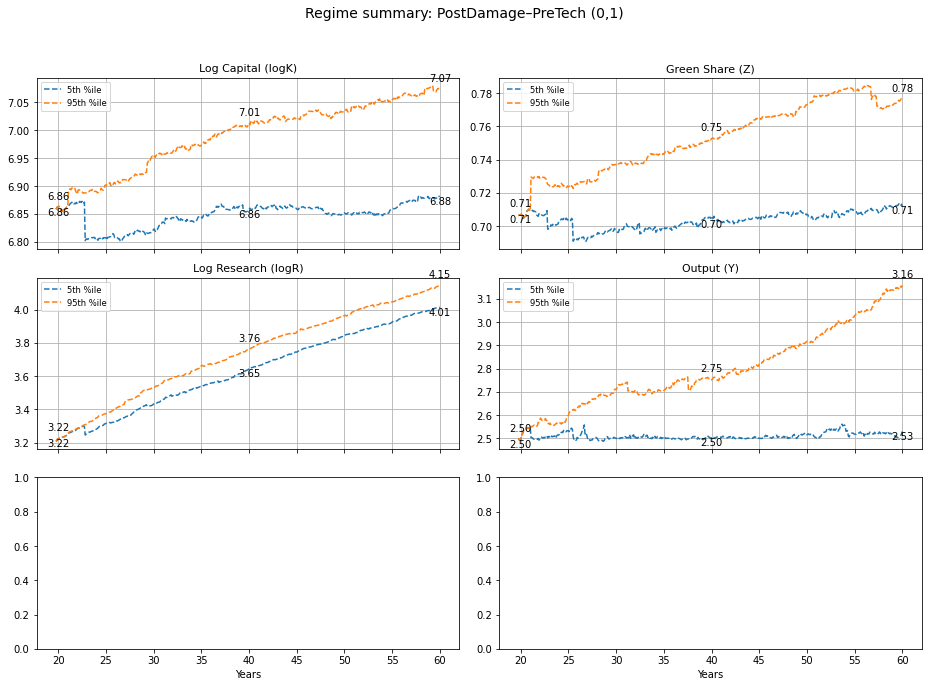


Regime: PreDamage–IntermTech (1,0) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8314, 95th %ile = 6.9716
  Year 40: 5th %ile = 6.9032, 95th %ile = 7.1270
  Year 60: 5th %ile = 6.9689, 95th %ile = 7.2865

Regime: PreDamage–IntermTech (1,0) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.6988, 95th %ile = 0.7477
  Year 40: 5th %ile = 0.7155, 95th %ile = 0.7858
  Year 60: 5th %ile = 0.7411, 95th %ile = 0.8169

Regime: PreDamage–IntermTech (1,0) | Variable: Log Research (logR)
  Year 20: 5th %ile = 3.1410, 95th %ile = 3.2390
  Year 40: 5th %ile = 3.6429, 95th %ile = 3.7714
  Year 60: 5th %ile = 4.0189, 95th %ile = 4.1824

Regime: PreDamage–IntermTech (1,0) | Variable: Output (Y)
  Year 20: 5th %ile = 1.3433, 95th %ile = 1.6342
  Year 40: 5th %ile = 1.6643, 95th %ile = 2.0155
  Year 60: 5th %ile = 1.9098, 95th %ile = 2.3543


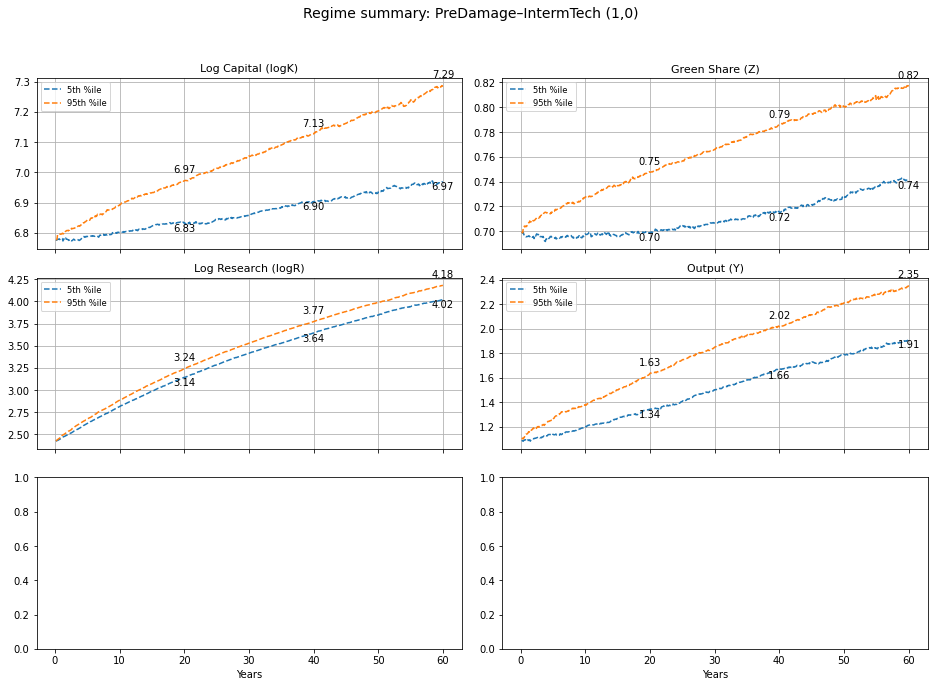


Regime: PostDamage–IntermTech (1,1) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8302, 95th %ile = 6.8513
  Year 40: 5th %ile = 6.9123, 95th %ile = 7.1237
  Year 60: 5th %ile = 6.9899, 95th %ile = 7.2807

Regime: PostDamage–IntermTech (1,1) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.7050, 95th %ile = 0.7083
  Year 40: 5th %ile = 0.7175, 95th %ile = 0.7753
  Year 60: 5th %ile = 0.7405, 95th %ile = 0.8170

Regime: PostDamage–IntermTech (1,1) | Variable: Log Research (logR)
  Year 20: 5th %ile = 3.1224, 95th %ile = 3.1343
  Year 40: 5th %ile = 3.6525, 95th %ile = 3.7884
  Year 60: 5th %ile = 4.0253, 95th %ile = 4.1822

Regime: PostDamage–IntermTech (1,1) | Variable: Output (Y)
  Year 20: 5th %ile = 2.4937, 95th %ile = 2.5005
  Year 40: 5th %ile = 2.4978, 95th %ile = 2.8523
  Year 60: 5th %ile = 2.5289, 95th %ile = 3.1338


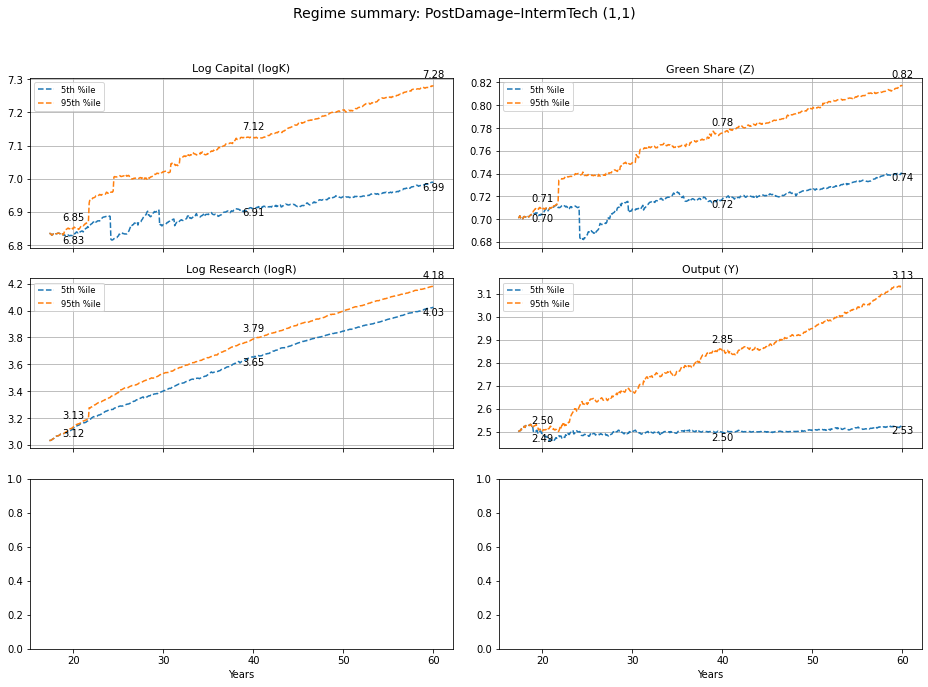


Regime: PreDamage–PostTech (2,0) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8790, 95th %ile = 7.0706
  Year 40: 5th %ile = 6.9356, 95th %ile = 7.3786
  Year 60: 5th %ile = 7.1534, 95th %ile = 7.7422

Regime: PreDamage–PostTech (2,0) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.7219, 95th %ile = 0.7940
  Year 40: 5th %ile = 0.7371, 95th %ile = 0.8568
  Year 60: 5th %ile = 0.7845, 95th %ile = 0.9077

Regime: PreDamage–PostTech (2,0) | Variable: Log Research (logR)
  Year 20: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: PreDamage–PostTech (2,0) | Variable: Output (Y)
  Year 20: 5th %ile = 1.3431, 95th %ile = 1.5624
  Year 40: 5th %ile = 1.6190, 95th %ile = 2.0504
  Year 60: 5th %ile = 1.9486, 95th %ile = 2.3038


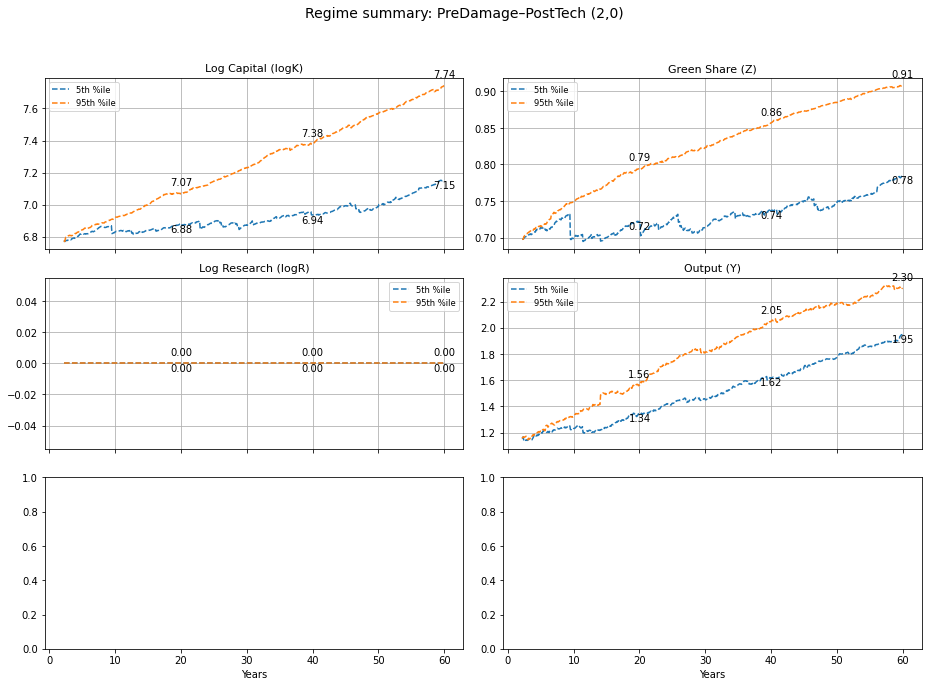


Regime: PostDamage–PostTech (2,1) | Variable: Log Capital (logK)
  Year 20: insufficient data in this regime at that time
  Year 40: 5th %ile = 6.9486, 95th %ile = 7.3277
  Year 60: 5th %ile = 7.0936, 95th %ile = 7.6567

Regime: PostDamage–PostTech (2,1) | Variable: Green Share (Z)
  Year 20: insufficient data in this regime at that time
  Year 40: 5th %ile = 0.7481, 95th %ile = 0.8463
  Year 60: 5th %ile = 0.7777, 95th %ile = 0.8943

Regime: PostDamage–PostTech (2,1) | Variable: Log Research (logR)
  Year 20: insufficient data in this regime at that time
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: PostDamage–PostTech (2,1) | Variable: Output (Y)
  Year 20: insufficient data in this regime at that time
  Year 40: 5th %ile = 2.4943, 95th %ile = 2.7607
  Year 60: 5th %ile = 2.5251, 95th %ile = 3.0289


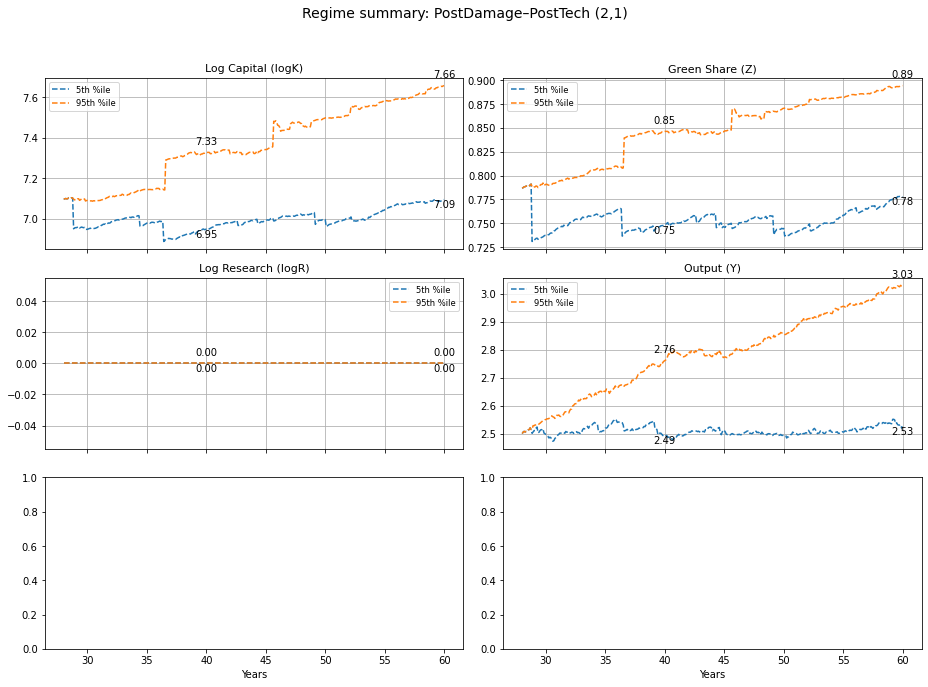

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ====== EDIT THIS to your simulation folder ======
data_folder = '/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/SimulationResults/paths_ξ_148.4'

# Variables to summarize (title -> file prefix)
variables = {
    'Log Capital (logK)':      'logK_sim_',
    'Green Share (Z)':         'Z_array_',
    'Log Research (logR)':     'logR_array_',
    'Output (Y)':              'Y_array_', 
}

def load_and_concat(folder, prefix):
    """
    Load all .npy files in 'folder' whose names start with 'prefix',
    sort them, and concatenate on axis=0 (paths).
    """
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        raise FileNotFoundError(f"No files for prefix '{prefix}' in {folder}")
    files.sort()
    arrays = [np.load(f) for f in files]
    # Ensure 2D arrays [n_paths, T+1]
    arrays = [a if a.ndim == 2 else np.atleast_2d(a) for a in arrays]
    return np.concatenate(arrays, axis=0)

# --- Load state arrays first (for masks/time axis) ---
tech_state = load_and_concat(data_folder, 'tech_state_array_')   # values in {0,1,2}
damage_state = load_and_concat(data_folder, 'damage_state_array_') # values in {0,1}

# Align time length to states
n_paths, n_steps = tech_state.shape
time_years = np.arange(n_steps) / 12.0   # includes t=0 at year 0

# Six-regime masks (shape: [n_paths, n_steps])
regimes = {
    'PreDamage–PreTech (0,0)':     (tech_state == 0) & (damage_state == 0),
    'PostDamage–PreTech (0,1)':    (tech_state == 0) & (damage_state == 1),
    'PreDamage–IntermTech (1,0)':  (tech_state == 1) & (damage_state == 0),
    'PostDamage–IntermTech (1,1)': (tech_state == 1) & (damage_state == 1),
    'PreDamage–PostTech (2,0)':    (tech_state == 2) & (damage_state == 0),
    'PostDamage–PostTech (2,1)':   (tech_state == 2) & (damage_state == 1),
}

# years to print percentiles for (indices at exact end-of-year)
annot_years = [20, 40, 60]
annot_idxs = [y*12 for y in annot_years if y*12 < n_steps]

# --- Load all variable arrays ---
data_arrays = {}
for label, prefix in variables.items():
    arr = load_and_concat(data_folder, prefix)
    # Trim/align time dimension if needed
    if arr.shape[1] > n_steps:
        arr = arr[:, :n_steps]
    elif arr.shape[1] < n_steps:
        # If shorter, trim states to match (rare)
        tech_state = tech_state[:, :arr.shape[1]]
        damage_state = damage_state[:, :arr.shape[1]]
        n_steps = arr.shape[1]
        time_years = np.arange(n_steps) / 12.0
        annot_idxs = [y*12 for y in annot_years if y*12 < n_steps]
        # Recompute masks with new length
        regimes = {
            'PreDamage–PreTech (0,0)':     (tech_state == 0) & (damage_state == 0),
            'PostDamage–PreTech (0,1)':    (tech_state == 0) & (damage_state == 1),
            'PreDamage–IntermTech (1,0)':  (tech_state == 1) & (damage_state == 0),
            'PostDamage–IntermTech (1,1)': (tech_state == 1) & (damage_state == 1),
            'PreDamage–PostTech (2,0)':    (tech_state == 2) & (damage_state == 0),
            'PostDamage–PostTech (2,1)':   (tech_state == 2) & (damage_state == 1),
        }
    data_arrays[label] = arr

# --- Make one figure per regime (3x2 panels to show 6 variables) ---
labels_in_order = list(variables.keys())
nrows, ncols = 3, 2

for regime_label, mask in regimes.items():
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 10), sharex=True)
    axes = axes.flatten()

    for ax, var_label in zip(axes, labels_in_order):
        arr = data_arrays[var_label]   # shape [n_paths_total, n_steps]
        lower = np.full(n_steps, np.nan)
        upper = np.full(n_steps, np.nan)

        # compute 5th/95th across paths that are in this regime at time t
        for t in range(n_steps):
            sel = mask[:, t]
            if sel.any():
                vals = arr[sel, t]
                lower[t] = np.percentile(vals, 5)
                upper[t] = np.percentile(vals, 95)

        # --- Print selected-year percentiles ---
        print(f"\nRegime: {regime_label} | Variable: {var_label}")
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                print(f"  Year {y:2d}: 5th %ile = {lower[idx]:.4f}, 95th %ile = {upper[idx]:.4f}")
            else:
                print(f"  Year {y:2d}: insufficient data in this regime at that time")

        # Plot percentile bands (dashed lines)
        ax.plot(time_years, lower, linestyle='--', label='5th %ile')
        ax.plot(time_years, upper, linestyle='--', label='95th %ile')

        # Annotate the printed years
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                ax.annotate(f'{lower[idx]:.2f}', xy=(y, lower[idx]),
                            xytext=(0, -8), textcoords='offset points', ha='center')
            if not np.isnan(upper[idx]):
                ax.annotate(f'{upper[idx]:.2f}', xy=(y, upper[idx]),
                            xytext=(0,  8), textcoords='offset points', ha='center')

        ax.set_title(var_label, fontsize=11)
        ax.grid(True)
        ax.legend(fontsize='small')

    # labels & layout
    for ax in axes[-ncols:]:
        ax.set_xlabel('Years')
    fig.suptitle(f'Regime summary: {regime_label}', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


Regime: PreDamage–PreTech (0,0) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.7964, 95th %ile = 6.9034
  Year 40: 5th %ile = 6.8346, 95th %ile = 6.9844
  Year 60: 5th %ile = 6.8857, 95th %ile = 7.0611

Regime: PreDamage–PreTech (0,0) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.6916, 95th %ile = 0.7310
  Year 40: 5th %ile = 0.7049, 95th %ile = 0.7528
  Year 60: 5th %ile = 0.7230, 95th %ile = 0.7784

Regime: PreDamage–PreTech (0,0) | Variable: Log Research (logR)
  Year 20: 5th %ile = 3.1842, 95th %ile = 3.2812
  Year 40: 5th %ile = 3.7094, 95th %ile = 3.8340
  Year 60: 5th %ile = 4.1007, 95th %ile = 4.2535

Regime: PreDamage–PreTech (0,0) | Variable: Output (Y)
  Year 20: 5th %ile = 1.3394, 95th %ile = 1.6172
  Year 40: 5th %ile = 1.6637, 95th %ile = 2.0376
  Year 60: 5th %ile = 1.8689, 95th %ile = 2.3726

Regime: PreDamage–PreTech (0,0) | Variable: Tech Level A_g
  Year 20: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 6

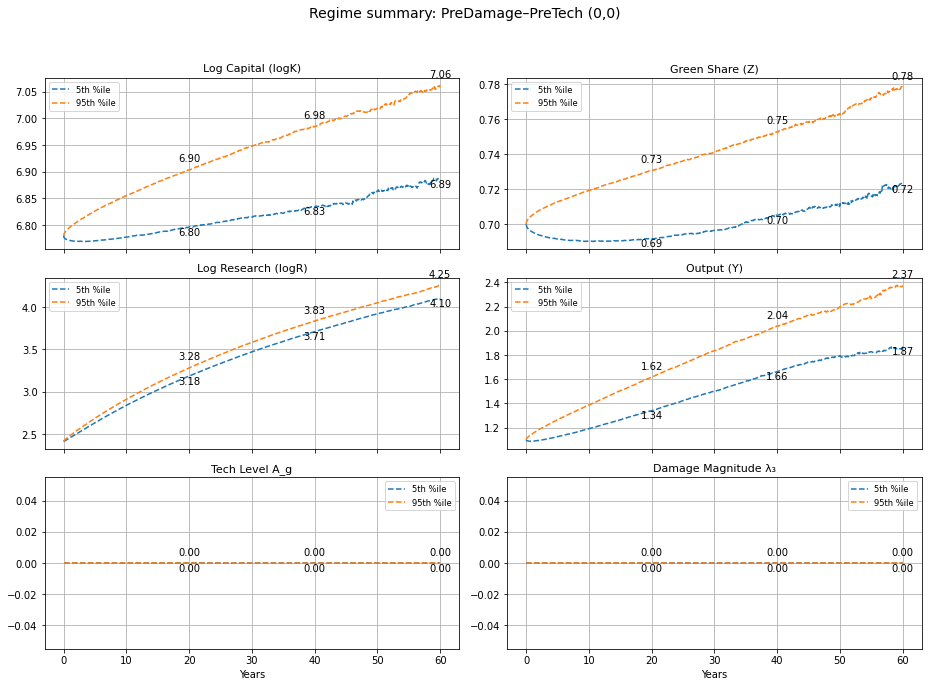


Regime: PostDamage–PreTech (0,1) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8186, 95th %ile = 6.8742
  Year 40: 5th %ile = 6.8300, 95th %ile = 6.9832
  Year 60: 5th %ile = 6.8700, 95th %ile = 7.0609

Regime: PostDamage–PreTech (0,1) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.6875, 95th %ile = 0.7239
  Year 40: 5th %ile = 0.7016, 95th %ile = 0.7512
  Year 60: 5th %ile = 0.7183, 95th %ile = 0.7765

Regime: PostDamage–PreTech (0,1) | Variable: Log Research (logR)
  Year 20: 5th %ile = 3.1843, 95th %ile = 3.2756
  Year 40: 5th %ile = 3.6970, 95th %ile = 3.8223
  Year 60: 5th %ile = 4.0534, 95th %ile = 4.2100

Regime: PostDamage–PreTech (0,1) | Variable: Output (Y)
  Year 20: 5th %ile = 2.5008, 95th %ile = 2.5893
  Year 40: 5th %ile = 2.4996, 95th %ile = 2.8164
  Year 60: 5th %ile = 2.5200, 95th %ile = 3.0713

Regime: PostDamage–PreTech (0,1) | Variable: Tech Level A_g
  Year 20: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Y

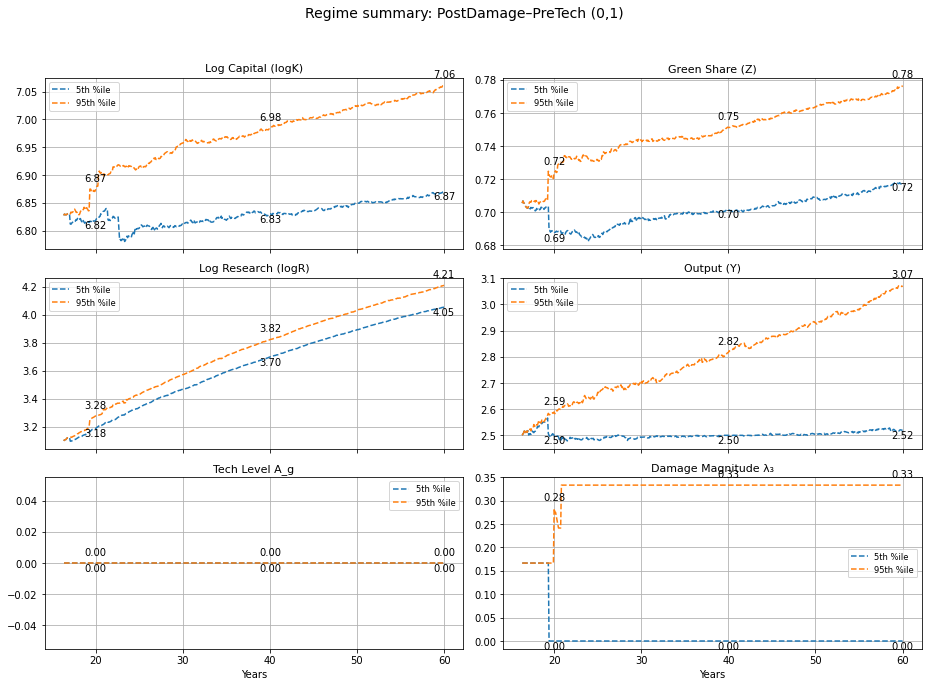


Regime: PreDamage–IntermTech (1,0) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8242, 95th %ile = 6.9627
  Year 40: 5th %ile = 6.8946, 95th %ile = 7.1167
  Year 60: 5th %ile = 6.9690, 95th %ile = 7.2657

Regime: PreDamage–IntermTech (1,0) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.6996, 95th %ile = 0.7454
  Year 40: 5th %ile = 0.7176, 95th %ile = 0.7795
  Year 60: 5th %ile = 0.7405, 95th %ile = 0.8110

Regime: PreDamage–IntermTech (1,0) | Variable: Log Research (logR)
  Year 20: 5th %ile = 3.1900, 95th %ile = 3.2868
  Year 40: 5th %ile = 3.7219, 95th %ile = 3.8559
  Year 60: 5th %ile = 4.1233, 95th %ile = 4.2826

Regime: PreDamage–IntermTech (1,0) | Variable: Output (Y)
  Year 20: 5th %ile = 1.3389, 95th %ile = 1.6230
  Year 40: 5th %ile = 1.6501, 95th %ile = 2.0326
  Year 60: 5th %ile = 1.9279, 95th %ile = 2.3656

Regime: PreDamage–IntermTech (1,0) | Variable: Tech Level A_g
  Year 20: 5th %ile = 0.1303, 95th %ile = 0.1303
  Year 40: 5th %ile = 0.1303, 95th %ile = 

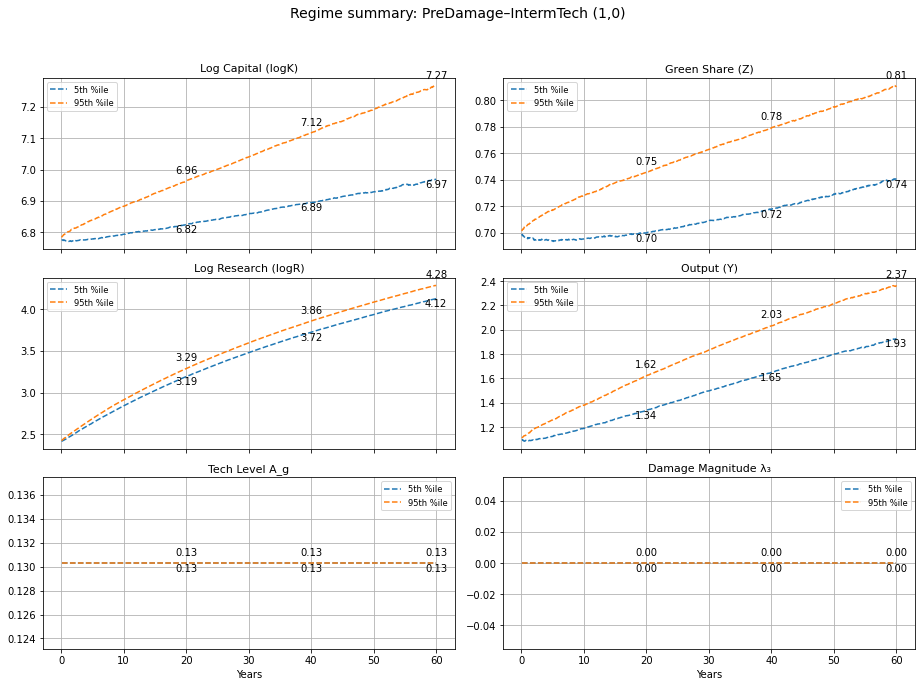


Regime: PostDamage–IntermTech (1,1) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8451, 95th %ile = 6.8959
  Year 40: 5th %ile = 6.8920, 95th %ile = 7.1210
  Year 60: 5th %ile = 6.9737, 95th %ile = 7.2742

Regime: PostDamage–IntermTech (1,1) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.7225, 95th %ile = 0.7327
  Year 40: 5th %ile = 0.7156, 95th %ile = 0.7759
  Year 60: 5th %ile = 0.7348, 95th %ile = 0.8065

Regime: PostDamage–IntermTech (1,1) | Variable: Log Research (logR)
  Year 20: 5th %ile = 3.2030, 95th %ile = 3.2281
  Year 40: 5th %ile = 3.7079, 95th %ile = 3.8452
  Year 60: 5th %ile = 4.0867, 95th %ile = 4.2602

Regime: PostDamage–IntermTech (1,1) | Variable: Output (Y)
  Year 20: 5th %ile = 2.4965, 95th %ile = 2.5182
  Year 40: 5th %ile = 2.5000, 95th %ile = 2.8257
  Year 60: 5th %ile = 2.5243, 95th %ile = 3.1527

Regime: PostDamage–IntermTech (1,1) | Variable: Tech Level A_g
  Year 20: 5th %ile = 0.1303, 95th %ile = 0.1303
  Year 40: 5th %ile = 0.1303, 95th %i

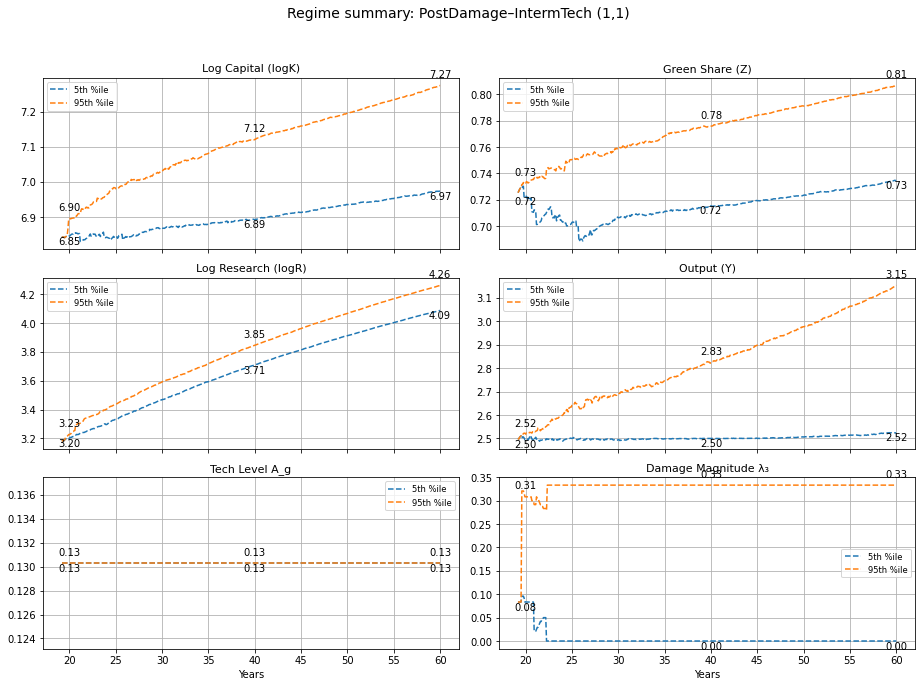


Regime: PreDamage–PostTech (2,0) | Variable: Log Capital (logK)
  Year 20: 5th %ile = 6.8529, 95th %ile = 7.0645
  Year 40: 5th %ile = 6.9320, 95th %ile = 7.3508
  Year 60: 5th %ile = 7.0346, 95th %ile = 7.6621

Regime: PreDamage–PostTech (2,0) | Variable: Green Share (Z)
  Year 20: 5th %ile = 0.7113, 95th %ile = 0.7917
  Year 40: 5th %ile = 0.7366, 95th %ile = 0.8528
  Year 60: 5th %ile = 0.7631, 95th %ile = 0.9023

Regime: PreDamage–PostTech (2,0) | Variable: Log Research (logR)
  Year 20: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: PreDamage–PostTech (2,0) | Variable: Output (Y)
  Year 20: 5th %ile = 1.3385, 95th %ile = 1.5994
  Year 40: 5th %ile = 1.6383, 95th %ile = 2.0255
  Year 60: 5th %ile = 1.8831, 95th %ile = 2.3204

Regime: PreDamage–PostTech (2,0) | Variable: Tech Level A_g
  Year 20: 5th %ile = 0.1567, 95th %ile = 0.1567
  Year 40: 5th %ile = 0.1567, 95th %ile = 0.1567
  Y

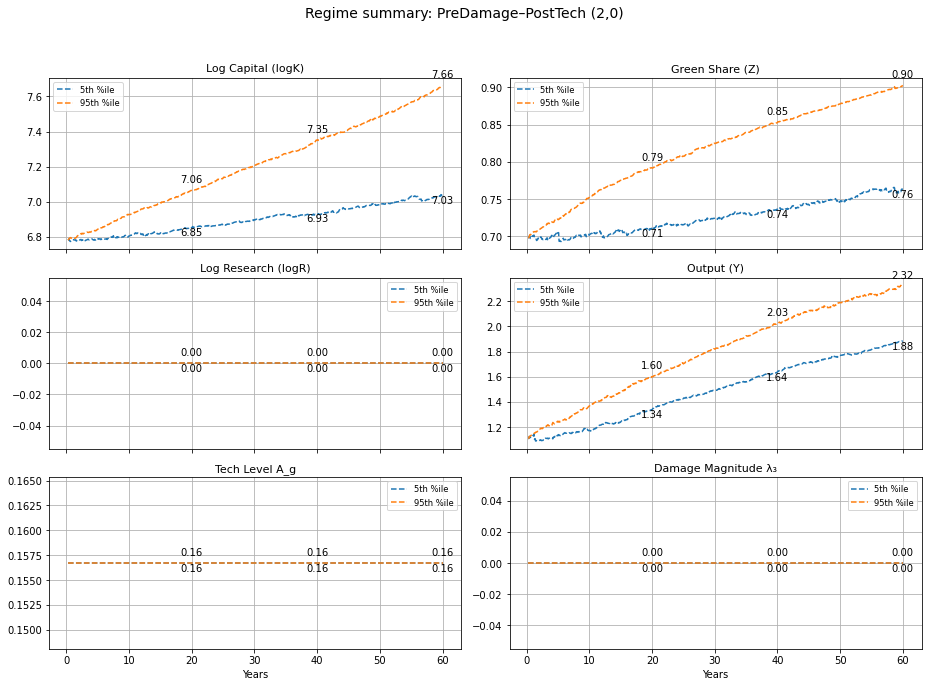


Regime: PostDamage–PostTech (2,1) | Variable: Log Capital (logK)
  Year 20: insufficient data in this regime at that time
  Year 40: 5th %ile = 6.9576, 95th %ile = 7.3296
  Year 60: 5th %ile = 7.0593, 95th %ile = 7.6203

Regime: PostDamage–PostTech (2,1) | Variable: Green Share (Z)
  Year 20: insufficient data in this regime at that time
  Year 40: 5th %ile = 0.7359, 95th %ile = 0.8517
  Year 60: 5th %ile = 0.7624, 95th %ile = 0.8970

Regime: PostDamage–PostTech (2,1) | Variable: Log Research (logR)
  Year 20: insufficient data in this regime at that time
  Year 40: 5th %ile = 0.0000, 95th %ile = 0.0000
  Year 60: 5th %ile = 0.0000, 95th %ile = 0.0000

Regime: PostDamage–PostTech (2,1) | Variable: Output (Y)
  Year 20: insufficient data in this regime at that time
  Year 40: 5th %ile = 2.4946, 95th %ile = 2.8100
  Year 60: 5th %ile = 2.5213, 95th %ile = 3.1303

Regime: PostDamage–PostTech (2,1) | Variable: Tech Level A_g
  Year 20: insufficient data in this regime at that time
  Year 

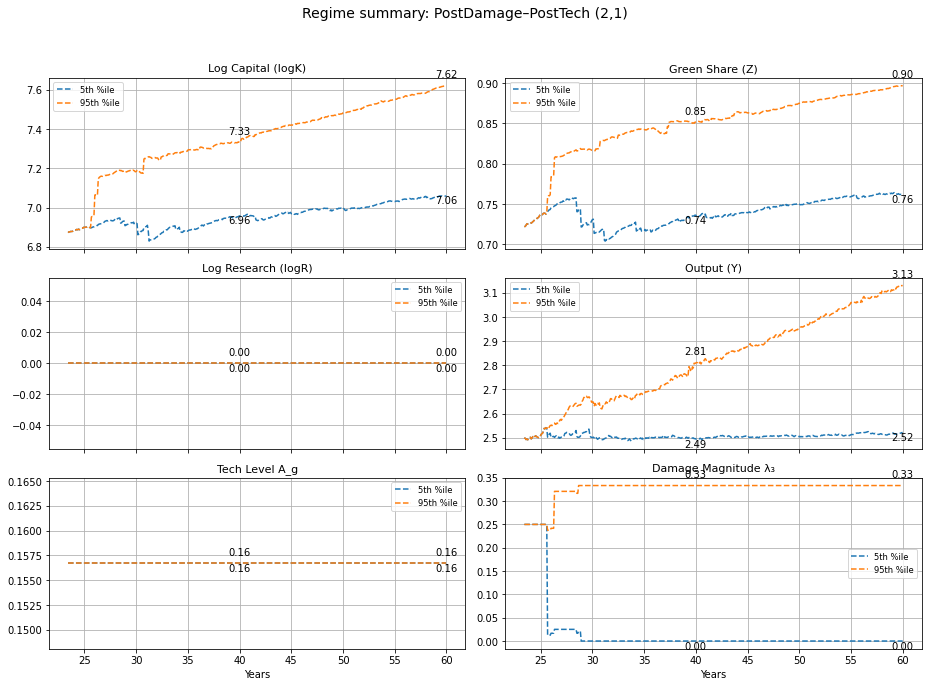

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ====== EDIT THIS to your simulation folder ======
data_folder = '/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/SimulationResults/paths_ξ_0.05'

# Variables to summarize (title -> file prefix)
variables = {
    'Log Capital (logK)':      'logK_sim_',
    'Green Share (Z)':         'Z_array_',
    'Log Research (logR)':     'logR_array_',
    'Output (Y)':              'Y_array_',
    'Tech Level A_g':          'A_g_array_',
    'Damage Magnitude λ₃':     'gamma3_array_',
}

def load_and_concat(folder, prefix):
    """
    Load all .npy files in 'folder' whose names start with 'prefix',
    sort them, and concatenate on axis=0 (paths).
    """
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        raise FileNotFoundError(f"No files for prefix '{prefix}' in {folder}")
    files.sort()
    arrays = [np.load(f) for f in files]
    # Ensure 2D arrays [n_paths, T+1]
    arrays = [a if a.ndim == 2 else np.atleast_2d(a) for a in arrays]
    return np.concatenate(arrays, axis=0)

# --- Load state arrays first (for masks/time axis) ---
tech_state = load_and_concat(data_folder, 'tech_state_array_')   # values in {0,1,2}
damage_state = load_and_concat(data_folder, 'damage_state_array_') # values in {0,1}

# Align time length to states
n_paths, n_steps = tech_state.shape
time_years = np.arange(n_steps) / 12.0   # includes t=0 at year 0

# Six-regime masks (shape: [n_paths, n_steps])
regimes = {
    'PreDamage–PreTech (0,0)':     (tech_state == 0) & (damage_state == 0),
    'PostDamage–PreTech (0,1)':    (tech_state == 0) & (damage_state == 1),
    'PreDamage–IntermTech (1,0)':  (tech_state == 1) & (damage_state == 0),
    'PostDamage–IntermTech (1,1)': (tech_state == 1) & (damage_state == 1),
    'PreDamage–PostTech (2,0)':    (tech_state == 2) & (damage_state == 0),
    'PostDamage–PostTech (2,1)':   (tech_state == 2) & (damage_state == 1),
}

# years to print percentiles for (indices at exact end-of-year)
annot_years = [20, 40, 60]
annot_idxs = [y*12 for y in annot_years if y*12 < n_steps]

# --- Load all variable arrays ---
data_arrays = {}
for label, prefix in variables.items():
    arr = load_and_concat(data_folder, prefix)
    # Trim/align time dimension if needed
    if arr.shape[1] > n_steps:
        arr = arr[:, :n_steps]
    elif arr.shape[1] < n_steps:
        # If shorter, trim states to match (rare)
        tech_state = tech_state[:, :arr.shape[1]]
        damage_state = damage_state[:, :arr.shape[1]]
        n_steps = arr.shape[1]
        time_years = np.arange(n_steps) / 12.0
        annot_idxs = [y*12 for y in annot_years if y*12 < n_steps]
        # Recompute masks with new length
        regimes = {
            'PreDamage–PreTech (0,0)':     (tech_state == 0) & (damage_state == 0),
            'PostDamage–PreTech (0,1)':    (tech_state == 0) & (damage_state == 1),
            'PreDamage–IntermTech (1,0)':  (tech_state == 1) & (damage_state == 0),
            'PostDamage–IntermTech (1,1)': (tech_state == 1) & (damage_state == 1),
            'PreDamage–PostTech (2,0)':    (tech_state == 2) & (damage_state == 0),
            'PostDamage–PostTech (2,1)':   (tech_state == 2) & (damage_state == 1),
        }
    data_arrays[label] = arr

# --- Make one figure per regime (3x2 panels to show 6 variables) ---
labels_in_order = list(variables.keys())
nrows, ncols = 3, 2

for regime_label, mask in regimes.items():
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 10), sharex=True)
    axes = axes.flatten()

    for ax, var_label in zip(axes, labels_in_order):
        arr = data_arrays[var_label]   # shape [n_paths_total, n_steps]
        lower = np.full(n_steps, np.nan)
        upper = np.full(n_steps, np.nan)

        # compute 5th/95th across paths that are in this regime at time t
        for t in range(n_steps):
            sel = mask[:, t]
            if sel.any():
                vals = arr[sel, t]
                lower[t] = np.percentile(vals, 5)
                upper[t] = np.percentile(vals, 95)

        # --- Print selected-year percentiles ---
        print(f"\nRegime: {regime_label} | Variable: {var_label}")
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                print(f"  Year {y:2d}: 5th %ile = {lower[idx]:.4f}, 95th %ile = {upper[idx]:.4f}")
            else:
                print(f"  Year {y:2d}: insufficient data in this regime at that time")

        # Plot percentile bands (dashed lines)
        ax.plot(time_years, lower, linestyle='--', label='5th %ile')
        ax.plot(time_years, upper, linestyle='--', label='95th %ile')

        # Annotate the printed years
        for y, idx in zip(annot_years, annot_idxs):
            if not np.isnan(lower[idx]):
                ax.annotate(f'{lower[idx]:.2f}', xy=(y, lower[idx]),
                            xytext=(0, -8), textcoords='offset points', ha='center')
            if not np.isnan(upper[idx]):
                ax.annotate(f'{upper[idx]:.2f}', xy=(y, upper[idx]),
                            xytext=(0,  8), textcoords='offset points', ha='center')

        ax.set_title(var_label, fontsize=11)
        ax.grid(True)
        ax.legend(fontsize='small')

    # labels & layout
    for ax in axes[-ncols:]:
        ax.set_xlabel('Years')
    fig.suptitle(f'Regime summary: {regime_label}', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()